In [9]:
# NPGA (ES gradients) with phi sampled from Drive CSV
# Two payment scenarios:
#   (A) Uniform market-clearing price (all winners paid p* = marginal accepted bid)
#   (B) Pay-as-bid (each winner paid own bid)
# Allocation: accept lowest bids until demand is met; capacity per supplier; bids above price cap are rejected.
# Utility: u_i = q_i_alloc * (payment_i - v_i) if accepted else 0.

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
#from google.colab import drive
import ast
import torch.nn.functional as F
from typing import Dict, Any
from typing import Dict, Any, List, Optional, Tuple
import numpy as np
import pandas as pd
import ast

In [10]:
import sys, torch
print(sys.version)
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)


3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
2.5.1+cu121
12.1
True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


## PARTE 0: CARGAR DATOS

In [11]:

# =========================
# 0) Load CSV from Drive
# =========================
#drive.mount("/content/drive")
CSV_PATH = "../../../results/fechas_117/TERMICA/inputRed.csv"   # <-- adjust
df = pd.read_csv(
    CSV_PATH,
    sep=";",
    decimal=",",      # 817128,3029 -> 817128.3029
    thousands="."     # si tienes 1.234.567,89
)
required = ['id_planta', "available_q", "phi", "precio_d", "daily_reman_demand"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}")

# Optional: if present, enables per-player phi sampling
AGENT_COL = "id_planta" if "id_planta" in df.columns else None


# =========================
# 1) Device / seeds
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(">>> Running on device:", device)

torch.manual_seed(0)
np.random.seed(0)

TensorDict = Dict[str, torch.Tensor]

>>> Running on device: cuda


In [14]:
len(df['id_planta'].unique())

36

## Cargar datos

In [15]:
import numpy as np
import pandas as pd
import ast


def _parse_available_q_24(x, *, fill_value=np.nan) -> np.ndarray:
    """
    Convierte available_q a vector (24,).
    Soporta: lista/np.array, string tipo "[...]", escalar, NaN.
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.full(24, float(fill_value), dtype=float)

    if isinstance(x, str):
        s = x.strip()
        if s == "" or s.lower() == "nan":
            return np.full(24, float(fill_value), dtype=float)
        # intenta parsear lista
        if s.startswith("[") and s.endswith("]"):
            x = ast.literal_eval(s)
        else:
            # escalar en string
            try:
                val = float(s)
                return np.full(24, val, dtype=float)
            except Exception:
                return np.full(24, float(fill_value), dtype=float)

    if isinstance(x, (list, tuple, np.ndarray)):
        a = np.asarray(x, dtype=float).reshape(-1)
        if a.size == 24:
            return a
        if a.size == 1:
            return np.full(24, float(a[0]), dtype=float)
        raise ValueError(f"available_q debe ser len=24 o escalar; got len={a.size}")

    # escalar numérico
    try:
        val = float(x)
        return np.full(24, val, dtype=float)
    except Exception:
        return np.full(24, float(fill_value), dtype=float)


def _kmeans_numpy(X: np.ndarray, k: int, *, seed: int = 123, max_iter: int = 200, tol: float = 1e-6):
    """
    K-means (numpy puro). X sin NaN. Retorna labels (n,) y centers (k,d).
    """
    rng = np.random.default_rng(int(seed))
    n, d = X.shape
    if not (1 <= k <= n):
        raise ValueError(f"G debe estar en [1,n]. G={k}, n={n}")

    # kmeans++ init
    centers = np.empty((k, d), dtype=float)
    i0 = int(rng.integers(0, n))
    centers[0] = X[i0]
    dist2 = np.sum((X - centers[0]) ** 2, axis=1)

    for j in range(1, k):
        s = dist2.sum()
        p = dist2 / s if s > 0 else np.full(n, 1.0 / n)
        ij = int(rng.choice(n, p=p))
        centers[j] = X[ij]
        dist2 = np.minimum(dist2, np.sum((X - centers[j]) ** 2, axis=1))

    labels = np.zeros(n, dtype=int)

    for _ in range(int(max_iter)):
        D = np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2)  # (n,k)
        new_labels = np.argmin(D, axis=1)

        new_centers = centers.copy()
        for j in range(k):
            idx = np.where(new_labels == j)[0]
            if idx.size == 0:
                new_centers[j] = X[int(rng.integers(0, n))]
            else:
                new_centers[j] = X[idx].mean(axis=0)

        shift = float(np.max(np.abs(new_centers - centers)))
        centers = new_centers
        labels = new_labels
        if shift < tol:
            break

    return labels, centers


def crear_columna_grupo(
    df: pd.DataFrame,
    *,
    G: int,
    id_col: str = "id_planta",
    avail_col: str = "available_q",
    phi_col: str = "phi",
    fecha_col: str = "Fecha",
    seed: int = 123,
) -> tuple[pd.DataFrame, dict[int, int]]:
    """
    Crea df["Grupo"] ∈ {1,...,G}.
    La asignación es por planta (id_planta), usando features por planta:
      - available_q (24)
      - estadísticos de phi (mediana y std), usando solo phi>0 para no contaminar con inactivos.
    Retorna: (df_con_grupo, gid_by_pid)
    """
    req = [id_col, avail_col, phi_col, fecha_col]
    miss = [c for c in req if c not in df.columns]
    if miss:
        raise KeyError(f"Faltan columnas requeridas: {miss}")

    d = df.copy()

    # 1) available_q “representativo” por planta: última observación según Fecha
    tmp = d[[id_col, fecha_col, avail_col]].copy()
    tmp[fecha_col] = pd.to_datetime(tmp[fecha_col], errors="coerce")
    tmp = tmp.sort_values([id_col, fecha_col], kind="mergesort")
    last_av = tmp.groupby(id_col, as_index=False).tail(1)[[id_col, avail_col]].copy()
    last_av["avail24"] = last_av[avail_col].apply(_parse_available_q_24)

    # 2) stats de phi por planta (solo phi>0)
    phi_num = pd.to_numeric(d[phi_col], errors="coerce")
    phi_df = pd.DataFrame({id_col: d[id_col].values, "phi": phi_num.values})
    phi_df = phi_df[np.isfinite(phi_df["phi"].values) & (phi_df["phi"].values > 0)]
    phi_stats = (
        phi_df.groupby(id_col, as_index=False)["phi"]
              .agg(phi_median="median", phi_std="std")
    )
    phi_stats["phi_std"] = phi_stats["phi_std"].fillna(0.0)

    # 3) features por planta
    feats = last_av.merge(phi_stats, on=id_col, how="left")
    feats["phi_median"] = feats["phi_median"].fillna(feats["phi_median"].median() if feats["phi_median"].notna().any() else 0.0)
    feats["phi_std"] = feats["phi_std"].fillna(0.0)

    X_av = np.vstack(feats["avail24"].to_numpy()).astype(float)               # (n,24)
    X_phi = feats[["phi_median", "phi_std"]].to_numpy(dtype=float)            # (n,2)
    X = np.hstack([X_av, X_phi])                                              # (n,26)

    # imputación NaN por mediana de columna
    col_med = np.nanmedian(X, axis=0)
    bad = ~np.isfinite(X)
    if bad.any():
        X[bad] = col_med[np.where(bad)[1]]

    # estandarización
    mu = X.mean(axis=0)
    sd = X.std(axis=0)
    sd[sd == 0] = 1.0
    Xz = (X - mu) / sd

    # 4) k-means → labels 0..G-1, guardamos 1..G
    labels0, _ = _kmeans_numpy(Xz, int(G), seed=int(seed))
    grupos = (labels0 + 1).astype(int)

    gid_by_pid = {int(pid): int(g) for pid, g in zip(feats[id_col].to_numpy(), grupos)}

    d["Grupo"] = d[id_col].map(gid_by_pid).astype("Int64")
    return d, gid_by_pid





In [16]:
def _aq24(x):
    if pd.isna(x):
        return np.full(24, np.nan)
    if isinstance(x, str):
        x = ast.literal_eval(x)
    a = np.asarray(x, float).reshape(-1)
    if a.size == 24:
        return a
    return np.full(24, float(a[0]) if a.size else np.nan)

def mean_por_hora_y_precio(df, grupo=None):
    grupo = grupo or ("Grupo" if "Grupo" in df.columns else "cluster")

    A = np.vstack(df["available_q"].apply(_aq24))  # (n,24)
    tmp = pd.concat(
        [
            df[[grupo]].rename(columns={grupo: "Grupo"}).reset_index(drop=True),
            pd.DataFrame(A, columns=[f"h{h+1}" for h in range(24)]),
            pd.to_numeric(df["precio_d"], errors="coerce").rename("precio_d").reset_index(drop=True),
        ],
        axis=1,
    )

    out = tmp.groupby("Grupo").mean(numeric_only=True).reset_index()
    return out[["Grupo"] + [f"h{i}" for i in range(1, 25)] + ["precio_d"]]

In [17]:
def mean_por_planta_y_hora(df, grupo=None):
    """
    Calcula el promedio horario (h1-h24) y precio por id_planta dentro de cada grupo/cluster.

    Args:
        df: dataframe que contiene columnas 'available_q', 'id_planta', 'precio_d', y 'cluster' o 'Grupo'.
        grupo: columna de agrupamiento (cluster o Grupo). Si no se da, busca 'Grupo' o 'cluster'.

    Returns:
        DataFrame con columnas: Grupo | id_planta | h1-h24 | precio_d
    """
    grupo = grupo or ("Grupo" if "Grupo" in df.columns else "cluster")

    # parse available_q -> (n,24)
    A = np.vstack(df["available_q"].apply(_parse_available_q_24).values)

    tmp = pd.concat(
        [
            df[[grupo, "id_planta"]].rename(columns={grupo: "Grupo"}).reset_index(drop=True),
            pd.DataFrame(A, columns=[f"h{i+1}" for i in range(24)]),
            pd.to_numeric(df["precio_d"], errors="coerce").rename("precio_d").reset_index(drop=True),
        ],
        axis=1,
    )

    # mean por id_planta dentro de cada Grupo
    out = (
        tmp
        .groupby(["Grupo", "id_planta"], as_index=False)
        .mean(numeric_only=True)
    )

    return out

In [18]:
import torch

def resolve_device_str(device="auto") -> str:
    if device == "auto":
        return "cuda" if torch.cuda.is_available() else "cpu"
    return str(device)


In [19]:
def get_torch_device(device: str = "auto") -> torch.device:
    """
    device:
      - "auto": cuda si disponible, si no cpu
      - "cuda": fuerza cuda (error si no hay)
      - "cpu": fuerza cpu
      - "cuda:0", "cuda:1", etc.
    """
    device = (device or "auto").lower().strip()
    if device == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device)

In [20]:
import numpy as np
import pandas as pd
import ast

SCALE = 1000.0

def div1000_list_string(x, scale=SCALE):
    # deja la columna como STRING tipo "[..., ...]" (igual estilo CSV)
    if x is None:
        return None
    if isinstance(x, float) and np.isnan(x):
        return np.nan

    # si viene como string "[...]" -> parse
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return None
        # si aparecen 'nan' en el string, literal_eval falla
        s = s.replace("nan", "None").replace("NaN", "None").replace("NAN", "None")
        L = ast.literal_eval(s)
    else:
        L = x  # ya es lista/array

    scaled = []
    for v in L:
        if v is None:
            scaled.append(None)
        else:
            fv = float(v)
            if np.isnan(fv):
                scaled.append(None)
            else:
                scaled.append(fv / scale)

    return str(scaled)  # vuelve a STRING con corchetes y comas

df = df.copy()

# listas como STRING (misma forma que originalmente)
df["available_q"] = df["available_q"].apply(div1000_list_string)
df["daily_reman_demand"] = df["daily_reman_demand"].apply(div1000_list_string)

# escalares (numéricos)
df["phi"] = pd.to_numeric(df["phi"], errors="coerce") / SCALE
df["precio_d"] = pd.to_numeric(df["precio_d"], errors="coerce") / SCALE

## FUNCIONES

## PARTE 1: SAMPLE OF VALUATIONS

In [21]:
def _to_24(x) -> np.ndarray:
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.full(24, np.nan, dtype=float)

    if isinstance(x, str):
        s = x.strip()
        if (s.startswith("[") and s.endswith("]")) or (s.startswith("(") and s.endswith(")")):
            x = ast.literal_eval(s)
        else:
            return np.full(24, float(s), dtype=float)

    if isinstance(x, (list, tuple, np.ndarray)):
        a = np.asarray(x, dtype=float).reshape(-1)
        if a.size == 24:
            return a
        if a.size == 1:
            return np.full(24, float(a[0]), dtype=float)
        raise ValueError(f"Se esperaba len 24 o escalar; got len={a.size}")

    return np.full(24, float(x), dtype=float)

def sample_day_batches_phi(
    df: pd.DataFrame,
    *,
    H: int,
    seed: int = 123,
    day_col: str = "dia",            # fecha/índice de día
    id_col: str = "id_planta",
    phi_col: str = "phi",
    price_col: Optional[str] = "precio_d",   # usado solo para detectar inactivos (phi=0 & precio=0)
    plant_ids: Optional[List[Any]] = None,
    replace: bool = False,
    min_active_plants: int = 1,      # filtra días con al menos este número de plantas activas
    pick: str = "random",            # si hay múltiples filas por (día,planta): "random" o "first"
) -> Tuple[np.ndarray, Dict[Any, np.ndarray], np.ndarray]:
    """
    Cada h es un día. Retorna:
      - days_sampled: (H,)
      - phi_batch_by_plant[pid]: (H,24)  (NaN si planta inactiva ese día)
      - active_mask: (H,I) bool
      -aunque verifico dias activos e inactivos, al final supuse que todas las plantas estaban activas en todos los dias
    """
    for c in (day_col, id_col, phi_col):
        if c not in df.columns:
            raise ValueError(f"df debe tener columna '{c}'")

    if plant_ids is None:
        plant_ids = list(pd.unique(df[id_col].values))

    d = df.loc[df[id_col].isin(plant_ids), [day_col, id_col, phi_col] + ([price_col] if (price_col and price_col in df.columns) else [])].copy()

    # activo: por defecto, phi no NaN
    active = np.isfinite(pd.to_numeric(d[phi_col], errors="coerce"))

    # si tienes regla de ceros-sentinela: (phi==0 & precio==0) => inactivo
    if price_col and price_col in d.columns:
        phi_num = pd.to_numeric(d[phi_col], errors="coerce")
        price_num = pd.to_numeric(d[price_col], errors="coerce")
        inactive_zero = (phi_num == 0) & (price_num == 0)
        active = active & (~inactive_zero)

    d["active"] = active

    # días elegibles: al menos min_active_plants activas
    active_counts = (
        d.loc[d["active"], [day_col, id_col]]
         .drop_duplicates()
         .groupby(day_col)[id_col]
         .nunique()
    )
    eligible_days = active_counts.index[active_counts.values >= int(min_active_plants)].to_numpy()
    if eligible_days.size == 0:
        raise ValueError("No hay días elegibles con el mínimo de plantas activas.")

    rng = np.random.default_rng(int(seed))
    days_sampled = rng.choice(eligible_days, size=int(H), replace=replace)

    I = len(plant_ids)
    phi_batch_by_plant: Dict[Any, np.ndarray] = {pid: np.full((H, 24), np.nan, dtype=float) for pid in plant_ids}
    active_mask = np.zeros((H, I), dtype=bool)

    # para lookup rápido
    d2 = d.drop_duplicates(subset=[day_col, id_col], keep="first") if pick == "first" else d

    for h_idx, day in enumerate(days_sampled):
        d_day = d2.loc[d2[day_col] == day]

        for j, pid in enumerate(plant_ids):
            rows = d_day.loc[d_day[id_col] == pid]
            if len(rows) == 0:
                continue

            if pick == "random" and len(rows) > 1:
                row = rows.iloc[int(rng.integers(0, len(rows)))]
            else:
                row = rows.iloc[0]

            if bool(row["active"]):
                active_mask[h_idx, j] = True
                phi_batch_by_plant[pid][h_idx, :] = _to_24(row[phi_col])

    return  phi_batch_by_plant

## PARTE 2

### PARTE 2.1 OBTENER BIDS

In [22]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn


class PolicyNet(nn.Module):
    def __init__(self, input_dim: int, hidden=(32, 64, 128, 128, 64, 32), output_dim: int = 1):
        super().__init__()
        layers = []
        d = int(input_dim)
        for h in hidden:
            layers += [nn.Linear(d, int(h)), nn.ReLU()]
            d = int(h)
        layers += [nn.Linear(d, int(output_dim))]
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def init_theta0_by_grupo_from_df(
    df,
    *,
    grupo_col="Grupo",     # <- columna de grupo (1..G)
    phi_col="phi",         # <- usa phi para b0
    input_dim=1,
    hidden=(32, 64, 128, 128, 64, 32),
    device=None,
    b0_mode="phi_median",  # "phi_median" o "phi_mean"
    money_scale=1.0,
    only_phi_pos=True,     # recomendado para no contaminar con inactivos
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if grupo_col not in df.columns:
        raise KeyError(f"df no tiene {grupo_col}")
    if phi_col not in df.columns:
        raise KeyError(f"df no tiene {phi_col}")

    d = df[[grupo_col, phi_col]].copy()
    d[phi_col] = pd.to_numeric(d[phi_col], errors="coerce")
    d[grupo_col] = pd.to_numeric(d[grupo_col], errors="coerce")
    d = d.dropna(subset=[grupo_col, phi_col])

    if only_phi_pos:
        d = d[d[phi_col] > 0]

    d[phi_col] = d[phi_col] / float(money_scale)

    if b0_mode == "phi_median":
        b0_by_g = d.groupby(grupo_col)[phi_col].median().to_dict()
    elif b0_mode == "phi_mean":
        b0_by_g = d.groupby(grupo_col)[phi_col].mean().to_dict()
    else:
        raise ValueError("b0_mode debe ser 'phi_median' o 'phi_mean'")

    theta_by_gid = {}
    L = len(hidden)
    last_bias_key = f"net.{2*L}.bias"

    for g, b0 in b0_by_g.items():
        g_int = int(g)
        model = PolicyNet(input_dim=input_dim, hidden=hidden, output_dim=1).to(device)
        sd = model.state_dict()

        # red constante al inicio: todo 0 y bias final=b0
        for k, v in sd.items():
            sd[k] = torch.zeros_like(v, device=device)

        sd[last_bias_key] = torch.tensor([float(b0)], dtype=sd[last_bias_key].dtype, device=device)

        theta_by_gid[g_int] = sd

    return theta_by_gid


In [23]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from typing import Dict, Any, List, Tuple

TensorDict = Dict[str, torch.Tensor]

# ----------------------------
# device
# ----------------------------
def _resolve_device(device="auto"):
    if device == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device)

# ----------------------------
# piso(phi) por escenario h
# ----------------------------
def _phi_floor_from_obs(obs: np.ndarray, floor_mode: str = "max") -> np.ndarray:
    obs = np.asarray(obs, dtype=np.float32)
    if obs.ndim == 1:
        return obs.astype(float)  # (H,)
    if obs.ndim == 2:
        if floor_mode == "max":
            return obs.max(axis=1).astype(float)
        if floor_mode == "mean":
            return obs.mean(axis=1).astype(float)
        raise ValueError("floor_mode must be 'max' or 'mean'")
    raise ValueError(f"obs shape no soportado: {obs.shape}")

# ----------------------------
# red
# ----------------------------
class PolicyNet(nn.Module):
    def __init__(self, input_dim: int, hidden=(32, 64, 128, 128, 64, 32), output_dim: int = 1):
        super().__init__()
        layers = []
        d = int(input_dim)
        for h in hidden:
            layers += [nn.Linear(d, int(h)), nn.ReLU()]
            d = int(h)
        layers += [nn.Linear(d, int(output_dim))]
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# ----------------------------
# init por GRUPO (tu función)
# ----------------------------
def init_theta0_by_grupo_from_df(
    df,
    *,
    grupo_col="Grupo",
    phi_col="phi",
    input_dim=1,
    hidden=(32, 64, 128, 128, 64, 32),
    device=None,
    b0_mode="phi_median",
    money_scale=1.0,
    only_phi_pos=True,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if grupo_col not in df.columns:
        raise KeyError(f"df no tiene {grupo_col}")
    if phi_col not in df.columns:
        raise KeyError(f"df no tiene {phi_col}")

    d = df[[grupo_col, phi_col]].copy()
    d[phi_col] = pd.to_numeric(d[phi_col], errors="coerce")
    d[grupo_col] = pd.to_numeric(d[grupo_col], errors="coerce")
    d = d.dropna(subset=[grupo_col, phi_col])

    if only_phi_pos:
        d = d[d[phi_col] > 0]

    d[phi_col] = d[phi_col] / float(money_scale)

    if b0_mode == "phi_median":
        b0_by_g = d.groupby(grupo_col)[phi_col].median().to_dict()
    elif b0_mode == "phi_mean":
        b0_by_g = d.groupby(grupo_col)[phi_col].mean().to_dict()
    else:
        raise ValueError("b0_mode debe ser 'phi_median' o 'phi_mean'")

    theta_by_gid = {}
    L = len(hidden)
    last_bias_key = f"net.{2*L}.bias"

    for g, b0 in b0_by_g.items():
        g_int = int(g)
        model = PolicyNet(input_dim=input_dim, hidden=hidden, output_dim=1).to(device)
        sd = model.state_dict()
        for k, v in sd.items():
            sd[k] = torch.zeros_like(v, device=device)
        sd[last_bias_key] = torch.tensor([float(b0)], dtype=sd[last_bias_key].dtype, device=device)
        theta_by_gid[g_int] = sd

    return theta_by_gid

# ----------------------------
# mapping pid -> gid y pid list por gid
# ----------------------------
def build_group_maps_from_df(df: pd.DataFrame, *, id_col="id_planta", grupo_col="Grupo"):
    if id_col not in df.columns:
        raise KeyError(f"df no tiene {id_col}")
    if grupo_col not in df.columns:
        raise KeyError(f"df no tiene {grupo_col}")

    x = df[[id_col, grupo_col]].copy()
    x[id_col] = pd.to_numeric(x[id_col], errors="coerce")
    x[grupo_col] = pd.to_numeric(x[grupo_col], errors="coerce")
    x = x.dropna(subset=[id_col, grupo_col])

    # si por error una planta tiene varios grupos en filas distintas, toma el modo
    def _mode1(s):
        m = s.mode()
        return int(m.iloc[0]) if len(m) else int(s.iloc[0])

    gid_by_pid = x.groupby(id_col)[grupo_col].apply(_mode1).to_dict()
    gid_by_pid = {int(pid): int(g) for pid, g in gid_by_pid.items()}

    pids_by_gid: Dict[int, List[int]] = {}
    for pid, g in gid_by_pid.items():
        pids_by_gid.setdefault(int(g), []).append(int(pid))

    for g in pids_by_gid:
        pids_by_gid[g] = sorted(pids_by_gid[g])

    return gid_by_pid, pids_by_gid

# ----------------------------
# nets por GRUPO
# ----------------------------
def build_nets_by_gid(
    theta_by_gid: Dict[int, TensorDict],
    *,
    input_dim: int,
    hidden=(32, 64, 128, 128, 64, 32),
    device="auto",
):
    dev = _resolve_device(device)
    nets_by_gid = {}
    for g, sd in theta_by_gid.items():
        net = PolicyNet(input_dim=input_dim, hidden=hidden, output_dim=1).to(dev)
        sd2 = {k: v.to(dev) for k, v in sd.items()}
        net.load_state_dict(sd2, strict=True)
        net.eval()
        nets_by_gid[int(g)] = net
    return nets_by_gid

# ----------------------------
# Beta por PLANTA usando red del GRUPO
# ----------------------------
def beta_matrix_from_obs_batch_grouped(
    nets_by_gid: Dict[int, PolicyNet],
    gid_by_pid: Dict[Any, int],
    obs_batch_by_pid: Dict[Any, np.ndarray],
    *,
    plant_ids: List[Any] = None,        # orden columnas; si None usa keys(obs_batch_by_pid)
    device="auto",
    enforce_beta_ge_phi=True,
    min_margin=1e-6,
    floor_mode="max",
    price_cap=None,
    return_numpy: bool = True,
):
    dev = _resolve_device(device)

    pids = list(plant_ids) if plant_ids is not None else list(obs_batch_by_pid.keys())
    pids = [int(p) for p in pids]

    H = int(np.asarray(obs_batch_by_pid[pids[0]]).shape[0])
    I = len(pids)

    Beta_t = torch.empty((H, I), dtype=torch.float32, device=dev)

    for j, pid in enumerate(pids):
        if pid not in gid_by_pid:
            raise KeyError(f"pid {pid} no tiene Grupo asignado (gid_by_pid).")
        g = int(gid_by_pid[pid])
        if g not in nets_by_gid:
            raise KeyError(f"No existe red para grupo g={g} en nets_by_gid.")

        net = nets_by_gid[g]  # ya está en dev y eval()

        obs_np = np.asarray(obs_batch_by_pid[pid], dtype=np.float32)
        if obs_np.ndim == 1:
            X = torch.as_tensor(obs_np.reshape(-1, 1), dtype=torch.float32, device=dev)
        elif obs_np.ndim == 2:
            X = torch.as_tensor(obs_np, dtype=torch.float32, device=dev)
        else:
            raise ValueError(f"obs_batch_by_pid[{pid}] shape no soportado: {obs_np.shape}")

        with torch.no_grad():
            b = net(X).reshape(-1)

            if enforce_beta_ge_phi:
                phi_floor = _phi_floor_from_obs(obs_np, floor_mode=floor_mode)
                phi_floor_t = torch.as_tensor(phi_floor, dtype=torch.float32, device=dev)
                b = torch.maximum(b, phi_floor_t + float(min_margin))

            if price_cap is not None:
                b = torch.minimum(b, torch.tensor(float(price_cap), dtype=torch.float32, device=dev))

            Beta_t[:, j] = b

    if return_numpy:
        return Beta_t.detach().cpu().numpy().astype(float), pids
    return Beta_t, pids

# ----------------------------
# Entry point: θ por GRUPO + redes por GRUPO + Beta por PLANTA
# ----------------------------
def policies_and_beta_profile_grouped(
    *,
    t: int,
    df: pd.DataFrame,
    obs_batch_by_pid: Dict[Any, np.ndarray],     # o_i^h (phi o vector 24h)
    theta_prev_by_gid: Dict[int, TensorDict] = None,
    id_col: str = "id_planta",
    grupo_col: str = "Grupo",
    phi_col: str = "phi",
    input_dim: int = 1,
    hidden=(32, 64, 128, 128, 64, 32),
    device: str = "auto",
    enforce_beta_ge_phi: bool = True,
    min_margin: float = 1e-6,
    floor_mode: str = "max",
    price_cap=None,
    plant_ids: List[Any] = None,
) -> dict:
    # mapas de grupos (para saber qué red usa cada planta)
    gid_by_pid, pids_by_gid = build_group_maps_from_df(df, id_col=id_col, grupo_col=grupo_col)

    # θ por grupo
    if int(t) == 0:
        theta_by_gid = init_theta0_by_grupo_from_df(
            df,
            grupo_col=grupo_col,
            phi_col=phi_col,
            input_dim=input_dim,
            hidden=hidden,
            device=_resolve_device(device),
        )
    else:
        if theta_prev_by_gid is None:
            raise ValueError("Para t>0 debes pasar theta_prev_by_gid = θ_{t-1} por grupo.")
        theta_by_gid = theta_prev_by_gid

    # redes por grupo
    nets_by_gid = build_nets_by_gid(theta_by_gid, input_dim=input_dim, hidden=hidden, device=device)

    # Beta por planta usando red del grupo correspondiente
    Beta, pids = beta_matrix_from_obs_batch_grouped(
        nets_by_gid,
        gid_by_pid,
        obs_batch_by_pid,
        plant_ids=plant_ids,
        device=device,
        enforce_beta_ge_phi=enforce_beta_ge_phi,
        min_margin=min_margin,
        floor_mode=floor_mode,
        price_cap=price_cap,
        return_numpy=True,
    )

    return {
        "theta_by_gid": theta_by_gid,
        "nets_by_gid": nets_by_gid,
        "gid_by_pid": gid_by_pid,
        "pids_by_gid": pids_by_gid,
        "Beta": Beta,
        "pids": pids,
    }




### PARTE 2.2 OBTENER EQUILIBRIO

In [24]:
# ----------------------------
# 1) Parse helpers
# ----------------------------
def _parse_vec24_allow_fill(x, fill_value=np.nan) -> np.ndarray:
    """
    Convierte a (24,) aceptando lista/array o string '[...]'.
    Si es escalar, lo repite 24.
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.full(24, float(fill_value), dtype=float)

    if isinstance(x, str):
        s = x.strip()
        if (s.startswith("[") and s.endswith("]")) or (s.startswith("(") and s.endswith(")")):
            x = ast.literal_eval(s)
        else:
            return np.full(24, float(s), dtype=float)

    if isinstance(x, (list, tuple, np.ndarray)):
        a = np.asarray(x, dtype=float).reshape(-1)
        if a.size == 24:
            return a
        if a.size == 1:
            return np.full(24, float(a[0]), dtype=float)
        raise ValueError(f"Se esperaba len 24 o escalar; got len={a.size}")

    return np.full(24, float(x), dtype=float)




def build_template_from_df(
    df: pd.DataFrame,
    *,
    id_col: str = "id_planta",
    avail_col: str = "available_q",
    demand_col: str = "daily_reman_demand",
) -> dict:
    """
    Output:
      template = {
        "I": array plant_ids (orden estable),
        "demanda": (24,),
        "_avail_mat": (I,24)
      }
    """
    for c in (id_col, avail_col, demand_col):
        if c not in df.columns:
            raise ValueError(f"Falta columna {c} en df")

    # demanda (24,)
    demand_raw = df[demand_col].dropna().iloc[-1]
    demand24 = _parse_vec24_allow_fill(demand_raw)

    # avail por planta (I,24) usando última fila por planta en orden estable
    last_av = (
        df.sort_index(kind="mergesort")
          .groupby(id_col, sort=False, as_index=False)
          .tail(1)[[id_col, avail_col]]
          .copy()
    )
    last_av["available_q_vec"] = last_av[avail_col].apply(_parse_vec24_allow_fill)

    plant_ids = [int(x) for x in last_av[id_col].to_numpy()]
    avail_mat = np.vstack(last_av["available_q_vec"].to_numpy()).astype(float)

    return {"I": np.array(plant_ids, dtype=int), "demanda": demand24.astype(float), "_avail_mat": avail_mat}

# ----------------------------
# 3) Construir juego_h desde Beta[h,:] y correr equilibrio
# ----------------------------
def compute_eq_for_batch_from_Beta(
    h_idx: int,
    *,
    template: dict,
    Beta: np.ndarray,                 # (H,I)
    pids: list,                       # len I
    compute_equilibrio_dispatch,      # tu función
    pricing: str = "uniform",
    unmet_price: float = np.nan,
) -> dict:
    plant_ids = [int(x) for x in np.asarray(template["I"]).reshape(-1)]
    avail_mat = np.asarray(template["_avail_mat"], dtype=float)
    demand24 = np.asarray(template["demanda"], dtype=float).reshape(24)

    Beta = np.asarray(Beta, dtype=float)
    if Beta.ndim != 2:
        raise ValueError(f"Beta debe ser 2D (H,I). Got shape={Beta.shape}")
    H, I = Beta.shape

    if not (0 <= h_idx < H):
        raise ValueError(f"h_idx fuera de rango. h_idx={h_idx}, H={H}")

    if len(pids) != I:
        raise ValueError(f"len(pids) debe ser I. len(pids)={len(pids)} vs I={I}")

    # map pid -> columna
    col = {int(pid): j for j, pid in enumerate(pids)}

    # chequeo: template plantas deben existir en pids
    missing = [pid for pid in plant_ids if pid not in col]
    if missing:
        raise KeyError(f"Estos pid del template no están en pids: {missing[:10]}")

    juego_h = {"I": np.array(plant_ids, dtype=int), "demanda": demand24.copy()}

    for r, pid in enumerate(plant_ids):
        j = col[pid]
        juego_h[pid] = {
            "beta": float(Beta[h_idx, j]),
            "available_q": avail_mat[r, :].copy(),
        }

    eq_h = compute_equilibrio_dispatch(juego_h, pricing=pricing, unmet_price=unmet_price)
    return eq_h

def compute_eq_over_batch_from_Beta(
    *,
    template: dict,
    Beta: np.ndarray,
    pids: list,
    compute_equilibrio_dispatch,
    pricing: str = "uniform",
    unmet_price: float = np.nan,
) -> list:
    Beta = np.asarray(Beta, dtype=float)
    H = int(Beta.shape[0])
    return [
        compute_eq_for_batch_from_Beta(
            h_idx=h,
            template=template,
            Beta=Beta,
            pids=pids,
            compute_equilibrio_dispatch=compute_equilibrio_dispatch,
            pricing=pricing,
            unmet_price=unmet_price,
        )
        for h in range(H)
    ]

In [25]:
import numpy as np

def compute_equilibrio_dispatch(juego: dict, pricing: str = "uniform", unmet_price="max_accepted"):
    """
    unmet_price:
      - número (float): usa ese precio si no hay dispatch
      - "max_accepted": si no hay dispatch, usa max bid positivo del sistema (si existe; si no, 0)
    """
    pricing = pricing.lower().strip()
    if pricing not in {"uniform", "pay_as_bid"}:
        raise ValueError("pricing must be 'uniform' or 'pay_as_bid'")

    # ids
    if "I" in juego:
        plant_ids = [int(x) for x in np.asarray(juego["I"]).reshape(-1)]
    else:
        plant_ids = [k for k in juego.keys() if isinstance(k, (int, np.integer))]

    if len(plant_ids) == 0:
        raise ValueError("No plant ids found in juego")

    demand24 = np.asarray(juego["demanda"], dtype=float).reshape(24)
    bids = np.array([float(juego[pid]["beta"]) for pid in plant_ids], dtype=float)  # (I,)
    avail_mat = np.vstack([np.asarray(juego[pid]["available_q"], dtype=float).reshape(24) for pid in plant_ids])  # (I,24)

    I = len(plant_ids)
    disp_mat = np.zeros((I, 24), dtype=float)
    price24 = np.zeros(24, dtype=float)  # nunca NaN

    # orden por bid (merit order), solo bids positivos
    active = bids > 0
    order = np.array([], dtype=int)
    if np.any(active):
        order = np.where(active)[0][np.argsort(bids[active], kind="mergesort")]

    # máximo bid positivo del sistema (para el caso “nadie despacha”)
    max_bid_pos = float(np.max(bids[active])) if np.any(active) else 0.0

    for h in range(24):
        remaining = float(max(demand24[h], 0.0))
        if remaining <= 0:
            price24[h] = 0.0
            continue

        av_h = np.maximum(avail_mat[:, h], 0.0)
        last_bid = None
        any_dispatch = False

        for i in order:
            if remaining <= 0:
                break
            take = min(av_h[i], remaining)
            if take > 0:
                disp_mat[i, h] = take
                remaining -= take
                any_dispatch = True
                last_bid = float(bids[i])

        # precio
        if any_dispatch:
            # “máximo aceptado” (marginal) incluso si quedó demanda sin cubrir
            price24[h] = float(last_bid)
        else:
            # nadie despachó -> evita NaN
            if unmet_price == "max_accepted":
                price24[h] = max_bid_pos
            else:
                price24[h] = float(unmet_price)

    # precio pagado por planta/hora
    if pricing == "uniform":
        precio_mat = np.where(disp_mat > 0.0, price24.reshape(1, 24), 0.0)
    else:
        precio_mat = np.where(disp_mat > 0.0, bids.reshape(I, 1), 0.0)

    eq = {
        "I": np.array(plant_ids, dtype=int),
        "demanda": demand24.copy(),
        "pricing": pricing,
        "price24": price24.copy(),
    }

    for idx, pid in enumerate(plant_ids):
        q = disp_mat[idx, :].copy()
        eq[pid] = {
            "beta": float(bids[idx]),
            "available_q": avail_mat[idx, :].copy(),
            "cantidades_despachadas": q,
            "precio24": precio_mat[idx, :].copy(),
            "sumaq": float(q.sum()),
        }
        if isinstance(juego.get(pid, {}), dict) and ("CodigoPlanta" in juego[pid]):
            eq[pid]["CodigoPlanta"] = juego[pid]["CodigoPlanta"]

    return eq

## PARTE 3

In [26]:
import numpy as np
from typing import Dict, Any, List, Tuple

def joint_utility_from_eq_list(
    eq_list: List[dict],                          # salida de compute_equilibrio_dispatch para cada h
    phi_batch_by_pid: Dict[Any, np.ndarray],      # phi_batch_by_pid[pid] = (H,24) o (H,)
    *,
    pricing: str = "uniform",
) -> Tuple[float, np.ndarray, Dict[Any, dict]]:
    """
    Calcula:
      U_total_by_batch[h] = sum_i u_i(h)
      U_total_mean        = mean_h U_total_by_batch[h]
      out_by_plant        = dict con utilidades por planta (mean y por batch)

    Convención de utilidad por planta i en escenario h:
      u_i(h) = sum_{t=1}^{24} q_{i,h,t} * (pago_{i,h,t} - phi_{i,h,t})

    donde:
      - q_{i,h,t} viene de eq_h[pid]["cantidades_despachadas"]
      - pago_{i,h,t} viene de eq_h[pid]["precio24"]
      - phi_{i,h,t} viene de phi_batch_by_pid[pid][h] (si escalar, se repite 24)

    Nota: el outcome (q, precios) ya viene dentro de eq_list y depende de β(o^h).
    """
    if len(eq_list) == 0:
        raise ValueError("eq_list vacío")

    H = len(eq_list)
    plant_ids = [int(x) for x in np.asarray(eq_list[0]["I"]).reshape(-1)]

    # utilidades por planta y por batch
    u_by_pid = {pid: np.zeros(H, dtype=float) for pid in plant_ids}

    for h_idx, eq_h in enumerate(eq_list):
        for pid in plant_ids:
            q24 = np.asarray(eq_h[pid]["cantidades_despachadas"], dtype=float).reshape(-1)
            if q24.size != 24:
                raise ValueError(f"pid={pid}: cantidades_despachadas debe tener 24, got {q24.size}")

            pay24 = np.asarray(eq_h[pid]["precio24"], dtype=float).reshape(-1)
            if pay24.size != 24:
                raise ValueError(f"pid={pid}: precio24 debe tener 24, got {pay24.size}")

            phi_h = np.asarray(phi_batch_by_pid[pid])
            if phi_h.ndim == 1:
                # escalar por h -> repetir 24
                c24 = np.full(24, float(phi_h[h_idx]), dtype=float)
            elif phi_h.ndim == 2:
                c24 = np.asarray(phi_h[h_idx, :], dtype=float).reshape(-1)
                if c24.size != 24:
                    raise ValueError(f"pid={pid}: phi_h[h] debe tener 24, got {c24.size}")
            else:
                raise ValueError(f"pid={pid}: phi_batch_by_pid[pid] shape no soportado {phi_h.shape}")

            u_by_pid[pid][h_idx] = float((q24 * (pay24 - c24)).sum())

    # utilidad conjunta por batch: sum_i u_i(h)
    U_total_by_batch = np.zeros(H, dtype=float)
    for h_idx in range(H):
        U_total_by_batch[h_idx] = sum(u_by_pid[pid][h_idx] for pid in plant_ids)

    U_total_mean = float(U_total_by_batch.mean())

    # salida detallada por planta
    out_by_plant: Dict[Any, dict] = {}
    for pid in plant_ids:
        out_by_plant[pid] = {
            "u_mean": float(u_by_pid[pid].mean()),
            "u_by_batch": u_by_pid[pid].copy(),
        }

    out_by_plant["_meta"] = {"pricing": str(pricing), "H": int(H), "plant_ids": plant_ids}

    return U_total_mean, U_total_by_batch, out_by_plant


In [27]:

# ============================================================
# FAST ORACLE (vectorized): utilities from Beta without eq dicts
# ============================================================
import numpy as np
from typing import Optional, Dict, Any

def _phi_tensor_from_dict(phi_batch_by_pid: Dict[int, np.ndarray], plant_ids_template: np.ndarray) -> np.ndarray:
    """
    Build phi_tensor aligned with template plant order.

    Returns:
      phi_tensor: (H, I, 24) float32
    """
    plant_ids_template = np.asarray(plant_ids_template, dtype=int).reshape(-1)
    sample = np.asarray(phi_batch_by_pid[int(plant_ids_template[0])])
    H = int(sample.shape[0])

    phi_list = []
    for pid in plant_ids_template:
        a = np.asarray(phi_batch_by_pid[int(pid)])
        if a.ndim == 1:
            # (H,) -> (H,24)
            if int(a.shape[0]) != H:
                raise ValueError(f"pid={pid}: H inconsistente en phi. Esperado {H}, got {a.shape[0]}")
            a24 = np.repeat(a.reshape(H, 1), 24, axis=1)
        elif a.ndim == 2:
            if int(a.shape[0]) != H:
                raise ValueError(f"pid={pid}: H inconsistente en phi. Esperado {H}, got {a.shape[0]}")
            if int(a.shape[1]) != 24:
                raise ValueError(f"pid={pid}: phi debe tener 24 columnas, got {a.shape[1]}")
            a24 = a
        else:
            raise ValueError(f"pid={pid}: phi shape no soportado {a.shape}")
        phi_list.append(a24.astype(np.float32, copy=False))

    # (I,H,24) -> (H,I,24)
    phi_tensor = np.stack(phi_list, axis=0).transpose(1, 0, 2).astype(np.float32, copy=False)
    return phi_tensor

def utilities_oracle_batch_from_bids(
    bids_batch: np.ndarray,          # (H, I)
    *,
    avail_mat: np.ndarray,           # (I,24) aligned with bids columns
    demand24: np.ndarray,            # (24,)
    phi_tensor: np.ndarray,          # (H,I,24) aligned with bids columns
    pricing: str = "uniform",
    unmet_price: Any = "max_accepted",
    group_mask: Optional[np.ndarray] = None,   # (I,) float weights or 0/1
) -> Dict[str, Any]:
    """
    Vectorized oracle:
      - sorts bids per scenario (axis=1)
      - dispatches per hour using cumulative availability
      - computes utilities using phi_tensor

    Returns dict:
      {
        "U_total_mean": float,
        "U_total_by_batch": (H,),
        "U_group_mean": float or None,
        "U_group_by_batch": (H,) or None,
      }
    """
    pricing = str(pricing).lower().strip()
    if pricing not in {"uniform", "pay_as_bid"}:
        raise ValueError("pricing must be 'uniform' or 'pay_as_bid'")

    bids_batch = np.asarray(bids_batch)
    if bids_batch.ndim != 2:
        raise ValueError(f"bids_batch debe ser 2D (H,I). Got shape={bids_batch.shape}")
    H, I = bids_batch.shape

    avail_mat = np.asarray(avail_mat)
    if avail_mat.shape != (I, 24):
        raise ValueError(f"avail_mat debe ser (I,24) con I={I}. Got {avail_mat.shape}")

    demand24 = np.asarray(demand24, dtype=np.float32).reshape(24)
    demand24 = np.maximum(demand24, 0.0)

    phi_tensor = np.asarray(phi_tensor, dtype=np.float32)
    if phi_tensor.shape != (H, I, 24):
        raise ValueError(f"phi_tensor debe ser (H,I,24) con H={H}, I={I}. Got {phi_tensor.shape}")

    # sort order: push non-positive bids to the end (treated as inactive)
    bids = bids_batch.astype(np.float32, copy=False)
    bids_eff = np.where(bids > 0.0, bids, np.inf).astype(np.float32, copy=False)
    order = np.argsort(bids_eff, axis=1, kind="mergesort")                    # (H,I)
    bids_s = np.take_along_axis(bids, order, axis=1)                          # (H,I)

    # avail sorted (H,I,24)
    avail_s = avail_mat[order].astype(np.float32, copy=False)                 # (H,I,24)
    avail_s = np.maximum(avail_s, 0.0)

    # deactivate bids<=0
    active_s = (bids_s > 0.0)
    avail_s *= active_s[:, :, None]

    # cumulative supply in merit order
    cum = np.cumsum(avail_s, axis=1)                                          # (H,I,24)
    totalcap = cum[:, -1, :]                                                  # (H,24)

    # full dispatch for plants strictly before marginal
    D = demand24.reshape(1, 1, 24)                                            # (1,1,24)
    full_mask = (cum < D)                                                     # (H,I,24)
    disp_full = avail_s * full_mask

    # marginal index per (H,hour)
    cond = (cum >= D)                                                         # (H,I,24)
    k = np.argmax(cond, axis=1).astype(np.int32)                              # (H,24) ; 0 if all False

    # whether a marginal exists (positive demand, positive cap, and D <= totalcap)
    D2 = demand24.reshape(1, 24)                                              # (1,24)
    need_partial = (D2 > 0.0) & (totalcap > 0.0) & (D2 <= totalcap)           # (H,24)

    # cum at k-1
    km1 = np.clip(k - 1, 0, I - 1).astype(np.int32)                           # (H,24)
    cum_km1 = np.take_along_axis(cum, km1[:, None, :], axis=1).squeeze(1)     # (H,24)
    cum_km1 = np.where(k == 0, 0.0, cum_km1)

    partial = (D2 - cum_km1).astype(np.float32)                               # (H,24)
    partial = np.where(need_partial, np.maximum(partial, 0.0), 0.0)

    # add partial dispatch to plant k
    disp_part = np.zeros((H, I, 24), dtype=np.float32)
    hh = np.arange(H, dtype=np.int32)[:, None]                                # (H,1)
    tt = np.arange(24, dtype=np.int32)[None, :]                               # (1,24)
    disp_part[hh, k, tt] = partial

    disp_s = disp_full + disp_part                                            # (H,I,24)

    # price per (H,hour)
    price = np.zeros((H, 24), dtype=np.float32)

    demand_pos = (D2 > 0.0)                                                   # (1,24)
    any_dispatch = (totalcap > 0.0) & demand_pos                               # (H,24)

    # max positive bid per scenario (for unmet_price="max_accepted")
    pos_bids = np.where(bids > 0.0, bids, -np.inf).astype(np.float32, copy=False)
    has_pos = np.isfinite(pos_bids).any(axis=1)
    max_bid_pos = np.where(has_pos, np.max(pos_bids, axis=1), 0.0).astype(np.float32)  # (H,)

    # marginal price (when D <= totalcap)
    price_marg = bids_s[hh, k]                                                 # (H,24)

    # last dispatched price (when D > totalcap but totalcap>0)
    mask_av = (avail_s > 0.0)                                                  # (H,I,24)
    rev = mask_av[:, ::-1, :]
    idx_from_end = np.argmax(rev, axis=1).astype(np.int32)                     # (H,24)
    last_idx = (I - 1 - idx_from_end).astype(np.int32)
    price_last = bids_s[hh, last_idx]                                          # (H,24)

    over = (D2 > totalcap) & (totalcap > 0.0) & demand_pos                     # (H,24)

    price[need_partial] = price_marg[need_partial]
    price[over] = price_last[over]

    # no dispatch but positive demand
    no_dispatch = demand_pos & (~any_dispatch)                                 # (H,24)
    if unmet_price == "max_accepted":
        max_bid_mat = np.repeat(max_bid_pos.reshape(H, 1), 24, axis=1)
        price[no_dispatch] = max_bid_mat[no_dispatch]
    else:
        price[no_dispatch] = float(unmet_price)

    # payment matrices
    if pricing == "uniform":
        pay_s = np.where(disp_s > 0.0, price[:, None, :], 0.0).astype(np.float32)
    else:
        pay_s = np.where(disp_s > 0.0, bids_s[:, :, None], 0.0).astype(np.float32)

    # phi sorted
    phi_s = phi_tensor[hh, order, :].astype(np.float32, copy=False)            # (H,I,24)

    # utilities per plant in sorted order: (H,I)
    u_s = np.sum(disp_s * (pay_s - phi_s), axis=2).astype(np.float32)

    U_total_by_batch = np.sum(u_s, axis=1).astype(np.float32)                  # (H,)
    U_total_mean = float(U_total_by_batch.mean())

    out = {
        "U_total_mean": U_total_mean,
        "U_total_by_batch": U_total_by_batch,
        "U_group_mean": None,
        "U_group_by_batch": None,
    }

    if group_mask is not None:
        gm = np.asarray(group_mask, dtype=np.float32).reshape(I)
        gm_s = gm[order]                                                       # (H,I)
        U_group_by_batch = np.sum(u_s * gm_s, axis=1).astype(np.float32)
        out["U_group_by_batch"] = U_group_by_batch
        out["U_group_mean"] = float(U_group_by_batch.mean())

    return out

def compute_beta_from_group_thetas_fast(
    *,
    theta_by_gid: dict,
    obs_batch_by_pid: dict,
    gid_by_pid: dict,
    pids: list,
    net_template_by_gid: dict,
    device="auto",
    min_bid=1e-6,
    floor_mode="max",
    reduce_mode="max",
) -> np.ndarray:
    """
    Same output as Beta in compute_beta_from_group_thetas, but evaluates per-group (single forward).
    Returns:
      Beta: (H, I=len(pids))
    """
    dev = resolve_device_str(device)
    pids = [int(p) for p in pids]
    H = int(np.asarray(obs_batch_by_pid[int(pids[0])]).shape[0])
    I = len(pids)

    # group -> list of pids in the order of 'pids'
    pids_in_group = {}
    cols_in_group = {}
    for j, pid in enumerate(pids):
        g = int(gid_by_pid[int(pid)])
        pids_in_group.setdefault(g, []).append(int(pid))
        cols_in_group.setdefault(g, []).append(int(j))

    Beta = np.empty((H, I), dtype=float)

    for g, pids_g in pids_in_group.items():
        g = int(g)
        theta_g = theta_by_gid[g]
        net_template = net_template_by_gid[g]
        betas_g = eval_policy_cols_for_pids_over_batch(
            net_template=net_template,
            theta=theta_g,
            obs_batch_by_pid=obs_batch_by_pid,
            pids_group=pids_g,
            device=dev,
            min_bid=min_bid,
            floor_mode=floor_mode,
            reduce_mode=reduce_mode,
        )  # (H,|G|)
        Beta[:, cols_in_group[g]] = betas_g

    return Beta


## PARTE 4: P PERTURBACIONES OF THE POLICY AND OBTAIN GRADIENT

In [28]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.func import functional_call

TensorDict = dict  # si ya lo tienes tipado como Dict[str, torch.Tensor], puedes borrar esta línea


def eval_policy_column_over_batch(
    *,
    net,
    theta: TensorDict,
    obs_batch: np.ndarray,        # (H,) o (H,24) o (H,d)
    device: str = "auto",
    min_bid: float = 1e-6,
    floor_mode: str = "max",      # si obs es 2D: max/mean para piso phi
    reduce_mode: str = "max",     # si red devuelve (H,24): max/mean para colapsar
) -> np.ndarray:
    dev = resolve_device_str(device)

    net = net.to(dev)
    net.eval()

    obs = np.asarray(obs_batch, dtype=np.float32)

    if obs.ndim == 1:
        X = torch.tensor(obs.reshape(-1, 1), dtype=torch.float32, device=dev)  # (H,1)
        floor = obs.astype(float)                                              # (H,)
    elif obs.ndim == 2:
        X = torch.tensor(obs, dtype=torch.float32, device=dev)                 # (H,d)
        if floor_mode == "max":
            floor = obs.max(axis=1).astype(float)                              # (H,)
        elif floor_mode == "mean":
            floor = obs.mean(axis=1).astype(float)                             # (H,)
        else:
            raise ValueError("floor_mode must be 'max' or 'mean'")
    else:
        raise ValueError(f"obs_batch shape no soportado: {obs.shape}")

    # mover theta a device (state_dict / tensores)
    theta_dev = {}
    for k, v in theta.items():
        if torch.is_tensor(v):
            theta_dev[k] = v.to(dev)
        else:
            theta_dev[k] = v

    with torch.no_grad():
        y = functional_call(net, theta_dev, (X,))  # (H,), (H,1), o (H,K)

        # colapsar salida a escalar por h
        if torch.is_tensor(y):
            if y.ndim == 2 and y.shape[1] > 1:
                if reduce_mode == "max":
                    raw = y.max(dim=1).values
                elif reduce_mode == "mean":
                    raw = y.mean(dim=1)
                else:
                    raise ValueError("reduce_mode must be 'max' or 'mean'")
            else:
                raw = y.reshape(-1)
        else:
            # si la red devuelve algo no-tensor (raro), intenta convertir
            y = torch.as_tensor(y, device=dev)
            raw = y.reshape(-1)

        inc = F.softplus(raw).detach().cpu().numpy().astype(float)             # >= 0
        beta = floor + inc + float(min_bid)                                    # (H,)

    return beta


In [29]:
def perturb_single_agent_es_individual(
    *,
    planta: int,
    theta_by_pid,
    net_by_pid,
    obs_batch_by_pid,
    phi_batch_by_pid,
    template,
    Beta_tminus1,
    pids,
    u_mean_base_planta: float,
    compute_equilibrio_dispatch,
    joint_utility_from_eq_list,
    pricing="uniform",
    unmet_price=np.nan,
    P=64,
    sigma=1e-3,
    seed=123,
    device="auto",
    min_bid=1e-6,
    floor_mode="max",
    reduce_mode="max",   # <-- AÑADIR
):
    import numpy as np
    import torch

    Beta_base = np.asarray(Beta_tminus1, dtype=float)
    H, I = Beta_base.shape

    planta = int(planta)
    col = {int(pid): j for j, pid in enumerate(pids)}
    if planta not in col:
        raise KeyError(f"planta={planta} no está en pids")
    j_planta = col[planta]

    theta0 = theta_by_pid[planta]

    grad = {
        k: torch.zeros_like(v)
        for k, v in theta0.items()
        if torch.is_tensor(v) and torch.is_floating_point(v)
    }

    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

    fitness_list = np.zeros(int(P), dtype=float)
    umean_list = np.zeros(int(P), dtype=float)

    for p in range(int(P)):
        # eps_p ~ N(0, sigma^2 I)  (perturbación directa)
        eps = {}
        theta_p = {}
        for k, v in theta0.items():
            if torch.is_tensor(v) and torch.is_floating_point(v):
                e = torch.randn_like(v) * float(sigma)
                eps[k] = e
                theta_p[k] = v + e
            else:
                theta_p[k] = v

        beta_col_p = eval_policy_column_over_batch(
            net=net_by_pid[planta],
            theta=theta_p,
            obs_batch=obs_batch_by_pid[planta],
            device=device,
            min_bid=min_bid,
            floor_mode=floor_mode,
            reduce_mode=reduce_mode,   # <-- PASAR
        )  # (H,)

        Beta_p = Beta_base.copy()
        Beta_p[:, j_planta] = beta_col_p

        eq_list_p = compute_eq_over_batch_from_Beta(
            template=template,
            Beta=Beta_p,
            pids=pids,
            compute_equilibrio_dispatch=compute_equilibrio_dispatch,
            pricing=pricing,
            unmet_price=unmet_price,
        )

        _Umean, _Ubyh, out_by_plant_p = joint_utility_from_eq_list(
            eq_list_p,
            phi_batch_by_pid=phi_batch_by_pid,
            pricing=pricing,
        )

        u_mean_p = float(out_by_plant_p[planta]["u_mean"])
        fitness = float(u_mean_p - float(u_mean_base_planta))

        fitness_list[p] = fitness
        umean_list[p] = u_mean_p

        for k in grad.keys():
            grad[k].add_(fitness * eps[k])

    # ∇ = 1/(sigma^2 P) Σ fitness * eps
    scale = 1.0 / (float(sigma) * float(sigma) * float(P))
    for k in grad.keys():
        grad[k].mul_(scale)

    return {
        "planta": int(planta),
        "col_index": int(j_planta),
        "grad_theta": grad,
        "fitness": fitness_list,
        "u_mean_pert": umean_list,
        "u_mean_base": float(u_mean_base_planta),
        "sigma": float(sigma),
        "P": int(P)
    }


In [30]:
import numpy as np
import pandas as pd
import torch
from typing import Dict, Any, List, Optional

TensorDict = Dict[str, torch.Tensor]

# ------------------------------------------------------------
# 0) pids_by_gid desde df (Grupo + id_planta)
# ------------------------------------------------------------
def build_pids_by_gid_from_df(df, *, id_col="id_planta", grupo_col="Grupo") -> Dict[int, List[int]]:
    x = df[[id_col, grupo_col]].copy()
    x[id_col] = pd.to_numeric(x[id_col], errors="coerce")
    x[grupo_col] = pd.to_numeric(x[grupo_col], errors="coerce")
    x = x.dropna(subset=[id_col, grupo_col])
    x[id_col] = x[id_col].astype(int)
    x[grupo_col] = x[grupo_col].astype(int)

    pids_by_gid: Dict[int, List[int]] = {}
    for g, sub in x.groupby(grupo_col, sort=True):
        pids_by_gid[int(g)] = sorted(sub[id_col].unique().tolist())
    return pids_by_gid

# ------------------------------------------------------------
# 1) aplicar gradiente ES al theta del grupo
# ------------------------------------------------------------
def apply_grad_to_theta(sd: TensorDict, grad: TensorDict, eta: float) -> TensorDict:
    out = {}
    for k, v in sd.items():
        if k in grad:
            out[k] = v + float(eta) * grad[k]
        else:
            out[k] = v
    return out

# ------------------------------------------------------------
# 2) utilidad agregada por grupo (mean sobre batch h)
# ------------------------------------------------------------
def group_utility_mean(
    out_by_plant: Dict[Any, dict],
    pids_group: List[int],
    *,
    weights_by_pid: Optional[Dict[int, float]] = None,
) -> float:
    if weights_by_pid is None:
        return float(sum(out_by_plant[int(pid)]["u_mean"] for pid in pids_group))
    return float(sum(float(weights_by_pid.get(int(pid), 0.0)) * float(out_by_plant[int(pid)]["u_mean"]) for pid in pids_group))

## PARTE 5: ACTUALIZAR BIDS

In [31]:
import numpy as np
import pandas as pd
import torch

def resolve_device_str(device="auto") -> str:
    if device == "auto":
        return "cuda" if torch.cuda.is_available() else "cpu"
    return str(device)

def build_gid_by_pid_from_df(df: pd.DataFrame, *, id_col="id_planta", grupo_col="Grupo") -> dict:
    x = df[[id_col, grupo_col]].copy()
    x[id_col] = pd.to_numeric(x[id_col], errors="coerce")
    x[grupo_col] = pd.to_numeric(x[grupo_col], errors="coerce")
    x = x.dropna(subset=[id_col, grupo_col]).drop_duplicates()
    x[id_col] = x[id_col].astype(int)
    x[grupo_col] = x[grupo_col].astype(int)
    return dict(zip(x[id_col].tolist(), x[grupo_col].tolist()))

def infer_input_dim_from_obs_batch(obs_batch_by_pid: dict) -> int:
    sample = np.asarray(next(iter(obs_batch_by_pid.values())))
    return 1 if sample.ndim == 1 else int(sample.shape[1])

def compute_beta_from_group_thetas(
    *,
    theta_by_gid: dict,                 # g -> state_dict (TensorDict)
    obs_batch_by_pid: dict,             # pid -> (H,) o (H,d)
    gid_by_pid: dict,                   # pid -> g
    pids: list,                         # orden columnas que quieres en Beta
    input_dim: int = None,              # si None, se infiere
    hidden=(32,64,128,128,64,32),
    device="auto",
    min_bid=1e-6,
    floor_mode="max",
    reduce_mode="max",
):
    """
    Devuelve:
      Beta: (H, I) con I=len(pids)
      beta_by_pid: dict pid -> (H,) (misma info, por si la quieres por planta)
      nets_by_gid: dict g -> PolicyNet (plantilla usada para functional_call)
    """
    dev = resolve_device_str(device)

    if input_dim is None:
        input_dim = infer_input_dim_from_obs_batch(obs_batch_by_pid)

    # plantilla por grupo (no necesita tener θ cargado porque eval_policy_column_over_batch usa functional_call)
    nets_by_gid = {}
    for g in theta_by_gid.keys():
        g = int(g)
        net = PolicyNet(input_dim=input_dim, hidden=hidden, output_dim=1).to(dev)
        net.eval()
        nets_by_gid[g] = net

    # H
    sample_pid = int(pids[0])
    H = int(np.asarray(obs_batch_by_pid[sample_pid]).shape[0])

    I = len(pids)
    Beta = np.empty((H, I), dtype=float)
    beta_by_pid = {}

    for j, pid in enumerate(pids):
        pid = int(pid)
        if pid not in gid_by_pid:
            raise KeyError(f"pid={pid} no está en gid_by_pid")
        g = int(gid_by_pid[pid])
        if g not in theta_by_gid:
            raise KeyError(f"grupo={g} no está en theta_by_gid")
        if pid not in obs_batch_by_pid:
            raise KeyError(f"pid={pid} no está en obs_batch_by_pid")

        obs = np.asarray(obs_batch_by_pid[pid])
        if int(obs.shape[0]) != H:
            raise ValueError(f"pid={pid}: H inconsistente. Esperado {H}, got {obs.shape[0]}")

        beta_col = eval_policy_column_over_batch(
            net=nets_by_gid[g],
            theta=theta_by_gid[g],
            obs_batch=obs_batch_by_pid[pid],
            device=dev,
            min_bid=min_bid,
            floor_mode=floor_mode,
            reduce_mode=reduce_mode,
        )  # (H,)

        Beta[:, j] = beta_col
        beta_by_pid[pid] = beta_col

    return Beta, beta_by_pid, nets_by_gid


## PARTE 6:SACAR BIDS Y CALCULAR EQUILIBRIOS

In [32]:
import numpy as np

def step_t_grouped(
    *,
    t: int,
    df,
    obs_batch_by_pid,                 # pid -> (H,) o (H,d)  (tus valuaciones/costos por batch)
    phi_batch_by_pid,                 # pid -> (H,) o (H,d)  (para utilidad; puede ser el mismo dict)
    theta_by_gid,                     # g -> state_dict
    net_by_gid,                       # g -> PolicyNet (plantilla o red)
    pids,                             # orden de plantas (columnas)
    compute_equilibrio_dispatch,
    joint_utility_from_eq_list,
    pricing="uniform",
    unmet_price="max_accepted",
    P=64,
    sigma=1e-3,
    eta=1e-2,
    seed=123,
    device="auto",
    hidden=(32,64,128,128,64,32),
    id_col="id_planta",
    grupo_col="Grupo",
    avail_col="available_q",
    demand_col="daily_reman_demand",
    min_bid=1e-6,
    floor_mode="max",
    reduce_mode="max",
):
    """
    Un paso t:
      1) construye Beta_t usando theta_by_gid por grupo
      2) calcula equilibrios eq_list_t
      3) calcula utilidades (U_mean_t, out_by_plant_t)
      4) corre ES por grupo (perturba θ_g y mueve todas las plantas del grupo) y actualiza theta_by_gid
    Retorna un dict con todo lo necesario para iterar.
    """

    # --- mappings + template ---
    gid_by_pid = build_gid_by_pid_from_df(df, id_col=id_col, grupo_col=grupo_col)
    template = build_template_from_df(df, id_col=id_col, avail_col=avail_col, demand_col=demand_col)

    # --- 1) Beta_t desde thetas por grupo ---
    input_dim = infer_input_dim_from_obs_batch(obs_batch_by_pid)
    Beta_t, beta_by_pid, nets_template = compute_beta_from_group_thetas(
        theta_by_gid=theta_by_gid,
        obs_batch_by_pid=obs_batch_by_pid,
        gid_by_pid=gid_by_pid,
        pids=pids,
        input_dim=input_dim,
        hidden=hidden,
        device=device,
        min_bid=min_bid,
        floor_mode=floor_mode,
        reduce_mode=reduce_mode,
    )

    # --- 2) eq_list_t ---
    eq_list_t = compute_eq_over_batch_from_Beta(
        template=template,
        Beta=Beta_t,
        pids=pids,
        compute_equilibrio_dispatch=compute_equilibrio_dispatch,
        pricing=pricing,
        unmet_price=unmet_price,
    )

    # --- 3) utilidades ---
    U_mean_t, U_by_h_t, out_by_plant_t = joint_utility_from_eq_list(
        eq_list_t,
        phi_batch_by_pid=phi_batch_by_pid,
        pricing=pricing,
    )

    # --- 4) ES por grupo (actualización por grupo) y update thetas ---
    # usa Beta_t como "Beta_tminus1" para evaluar perturbaciones alrededor del estado actual
    es_results_by_gid, theta_new_by_gid = run_es_for_all_groups_groupES(
        df=df,
        theta_by_gid=theta_by_gid,
        net_by_gid=net_by_gid,
        obs_batch_by_pid=obs_batch_by_pid,
        phi_batch_by_pid=phi_batch_by_pid,
        template=template,
        Beta_tminus1=Beta_t,
        pids=pids,
        compute_equilibrio_dispatch=compute_equilibrio_dispatch,
        joint_utility_from_eq_list=joint_utility_from_eq_list,
        pricing=pricing,
        unmet_price=unmet_price,
        P=P,
        sigma=sigma,
        seed=seed + 10000 * int(t),
        device=device,
        min_bid=min_bid,
        floor_mode=floor_mode,
        reduce_mode=reduce_mode,
        eta=eta,
        id_col=id_col,
        grupo_col=grupo_col,
    )

    # reconstruir nets_by_gid con thetas nuevos (para el siguiente t)
    net_by_gid_new = build_nets_by_gid(theta_new_by_gid, input_dim=input_dim, hidden=hidden, device=device)

    return {
        "t": int(t),
        "template": template,
        "gid_by_pid": gid_by_pid,
        "Beta_t": Beta_t,
        "beta_by_pid": beta_by_pid,
        "eq_list_t": eq_list_t,
        "U_mean_t": float(U_mean_t),
        "U_by_h_t": U_by_h_t,
        "out_by_plant_t": out_by_plant_t,
        "es_results_by_gid": es_results_by_gid,
        "theta_by_gid_new": theta_new_by_gid,
        "net_by_gid_new": net_by_gid_new,
        "nets_template": nets_template,
    }


## PARTE 7: CORRER TODO

In [33]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.func import functional_call
from typing import Dict, Any, List, Optional, Tuple

TensorDict = Dict[str, torch.Tensor]

def _theta_to_device(sd: TensorDict, dev: str) -> TensorDict:
    out = {}
    for k, v in sd.items():
        if torch.is_tensor(v):
            out[k] = v.to(dev)
        else:
            out[k] = v
    return out

def eval_policy_cols_for_pids_over_batch(
    *,
    net_template,
    theta: TensorDict,
    obs_batch_by_pid: Dict[int, np.ndarray],
    pids_group: List[int],
    device: str = "auto",
    min_bid: float = 1e-6,
    floor_mode: str = "max",     # si obs es (H,d): max/mean para piso
    reduce_mode: str = "max",    # si salida es (H,k): max/mean; con output_dim=1 no aplica, pero se deja
) -> np.ndarray:
    """
    Evalúa la política del grupo para múltiples plantas en un solo forward:
      retorna betas: (H, |pids_group|) con columnas alineadas a pids_group.
    Soporta obs por planta:
      - (H,)   -> input_dim=1
      - (H,d)  -> input_dim=d
    """
    dev = resolve_device_str(device)
    net_template = net_template.to(dev).eval()
    theta = _theta_to_device(theta, dev)

    pids_group = [int(p) for p in pids_group]
    if len(pids_group) == 0:
        raise ValueError("pids_group vacío")

    obs_list = [np.asarray(obs_batch_by_pid[int(pid)], dtype=np.float32) for pid in pids_group]
    H = int(obs_list[0].shape[0])

    # stack -> (G,H,d)
    if obs_list[0].ndim == 1:
        obs_stack = np.stack([o.reshape(H, 1) for o in obs_list], axis=0)  # (G,H,1)
        floor = obs_stack[..., 0].astype(np.float32)                        # (G,H)
        X = torch.as_tensor(obs_stack.reshape(-1, 1), dtype=torch.float32, device=dev)  # (G*H,1)
    elif obs_list[0].ndim == 2:
        d = int(obs_list[0].shape[1])
        obs_stack = np.stack(obs_list, axis=0)                              # (G,H,d)
        if floor_mode == "max":
            floor = obs_stack.max(axis=2).astype(np.float32)                # (G,H)
        elif floor_mode == "mean":
            floor = obs_stack.mean(axis=2).astype(np.float32)
        else:
            raise ValueError("floor_mode must be 'max' or 'mean'")
        X = torch.as_tensor(obs_stack.reshape(-1, d), dtype=torch.float32, device=dev)  # (G*H,d)
    else:
        raise ValueError(f"obs shape no soportado: {obs_list[0].shape}")

    with torch.no_grad():
        y = functional_call(net_template, theta, (X,))  # (G*H, outdim) o (G*H,)
        y = y.reshape(len(pids_group), H, -1)          # (G,H,k)
        if y.shape[-1] > 1:
            if reduce_mode == "max":
                y = y.max(dim=-1).values
            elif reduce_mode == "mean":
                y = y.mean(dim=-1)
            else:
                raise ValueError("reduce_mode must be 'max' or 'mean'")
        else:
            y = y.squeeze(-1)                          # (G,H)

        inc = F.softplus(y)                            # >=0
        floor_t = torch.as_tensor(floor, dtype=torch.float32, device=dev)
        b = floor_t + inc
        b = torch.clamp(b, min=float(min_bid))         # (G,H)

    betas = b.detach().cpu().numpy().astype(float)     # (G,H)
    return betas.T                                     # (H,G)

def perturb_group_es(
    *,
    gid: int,
    pids_group: List[int],
    theta_g: TensorDict,
    net_template,
    obs_batch_by_pid: Dict[int, np.ndarray],
    phi_batch_by_pid: Dict[int, np.ndarray],
    template: dict,
    Beta_base: np.ndarray,                  # (H,I) baseline con thetas actuales
    pids: List[int],                        # orden columnas en Beta_base
    compute_equilibrio_dispatch,
    joint_utility_from_eq_list,
    pricing: str = "uniform",
    unmet_price=np.nan,
    P: int = 64,
    sigma: float = 1e-3,
    seed: int = 123,
    device: str = "auto",
    min_bid: float = 1e-6,
    floor_mode: str = "max",
    reduce_mode: str = "max",
    weights_by_pid: Optional[Dict[int, float]] = None,
) -> Dict[str, Any]:
    """
    ES/NPGA a nivel de GRUPO: perturba θ_g y deja el resto fijo.
    La perturbación afecta TODAS las plantas en pids_group simultáneamente.
    Objetivo: U_g = sum_{i in group} u_i (mean sobre h).
    """
    dev = resolve_device_str(device)

    Beta_base = np.asarray(Beta_base, dtype=float)
    H, I = Beta_base.shape
    col = {int(pid): j for j, pid in enumerate(pids)}

    # grad init
    theta0 = _theta_to_device(theta_g, dev)
    grad = {
        k: torch.zeros_like(v)
        for k, v in theta0.items()
        if torch.is_tensor(v) and torch.is_floating_point(v)
    }

    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

    u_plus_list = np.zeros(int(P), dtype=float)
    u_minus_list = np.zeros(int(P), dtype=float)

    for p in range(int(P)):
        eps = {k: torch.randn_like(v) for k, v in grad.items()}

        theta_plus = {k: (theta0[k] + float(sigma) * eps[k]) if k in eps else theta0[k] for k in theta0}
        theta_minus = {k: (theta0[k] - float(sigma) * eps[k]) if k in eps else theta0[k] for k in theta0}

        # --- Beta plus/minus: solo columnas del grupo ---
        Beta_p = Beta_base.copy()
        Beta_m = Beta_base.copy()

        betas_plus = eval_policy_cols_for_pids_over_batch(
            net_template=net_template,
            theta=theta_plus,
            obs_batch_by_pid=obs_batch_by_pid,
            pids_group=pids_group,
            device=dev,
            min_bid=min_bid,
            floor_mode=floor_mode,
            reduce_mode=reduce_mode,
        )  # (H,|G|)

        betas_minus = eval_policy_cols_for_pids_over_batch(
            net_template=net_template,
            theta=theta_minus,
            obs_batch_by_pid=obs_batch_by_pid,
            pids_group=pids_group,
            device=dev,
            min_bid=min_bid,
            floor_mode=floor_mode,
            reduce_mode=reduce_mode,
        )

        for jg, pid in enumerate(pids_group):
            Beta_p[:, col[int(pid)]] = betas_plus[:, jg]
            Beta_m[:, col[int(pid)]] = betas_minus[:, jg]

        # --- equilibrio + utilidades ---
        eq_plus = compute_eq_over_batch_from_Beta(
            template=template,
            Beta=Beta_p,
            pids=pids,
            compute_equilibrio_dispatch=compute_equilibrio_dispatch,
            pricing=pricing,
            unmet_price=unmet_price,
        )
        _, _, out_plus = joint_utility_from_eq_list(eq_plus, phi_batch_by_pid=phi_batch_by_pid, pricing=pricing)
        U_plus = group_utility_mean(out_plus, pids_group, weights_by_pid=weights_by_pid)

        eq_minus = compute_eq_over_batch_from_Beta(
            template=template,
            Beta=Beta_m,
            pids=pids,
            compute_equilibrio_dispatch=compute_equilibrio_dispatch,
            pricing=pricing,
            unmet_price=unmet_price,
        )
        _, _, out_minus = joint_utility_from_eq_list(eq_minus, phi_batch_by_pid=phi_batch_by_pid, pricing=pricing)
        U_minus = group_utility_mean(out_minus, pids_group, weights_by_pid=weights_by_pid)

        u_plus_list[p] = float(U_plus)
        u_minus_list[p] = float(U_minus)

        diff = (float(U_plus) - float(U_minus)) / (2.0 * float(sigma))

        for k in grad.keys():
            grad[k] = grad[k] + (diff / float(P)) * eps[k]

    return {
        "gid": int(gid),
        "pids_group": [int(p) for p in pids_group],
        "grad_theta": {k: v.detach() for k, v in grad.items()},
        "U_plus_mean": float(u_plus_list.mean()),
        "U_minus_mean": float(u_minus_list.mean()),
        "U_diff_mean": float((u_plus_list - u_minus_list).mean() / (2.0 * float(sigma))),
    }


# ------------------------------------------------------------
# Fast ES for groups: avoids eq dicts; uses vectorized oracle
# ------------------------------------------------------------
def perturb_group_es_fast(
    *,
    gid: int,
    pids_group: List[int],
    theta_g: TensorDict,
    net_template,
    obs_batch_by_pid: Dict[int, np.ndarray],
    bids_template_base: np.ndarray,         # (H, I_template) baseline in TEMPLATE ORDER
    group_positions: np.ndarray,            # (|G|,) positions in TEMPLATE ORDER aligned to pids_group
    group_mask: np.ndarray,                 # (I_template,) float weights or 0/1
    avail_mat: np.ndarray,                  # (I_template,24)
    demand24: np.ndarray,                   # (24,)
    phi_tensor: np.ndarray,                 # (H,I_template,24)
    pricing: str = "uniform",
    unmet_price="max_accepted",
    P: int = 64,
    sigma: float = 1e-3,
    seed: int = 123,
    device: str = "auto",
    min_bid: float = 1e-6,
    floor_mode: str = "max",
    reduce_mode: str = "max",
) -> Dict[str, Any]:
    """
    ES/NPGA a nivel de GRUPO (fast path):
      - perturba θ_g
      - recomputa SOLO bids del grupo
      - computa U_g usando utilities_oracle_batch_from_bids (vectorizado)
    """
    dev = resolve_device_str(device)

    bids_template_base = np.asarray(bids_template_base, dtype=np.float32)
    if bids_template_base.ndim != 2:
        raise ValueError(f"bids_template_base debe ser 2D (H,I). Got {bids_template_base.shape}")
    H, Itemp = bids_template_base.shape

    group_positions = np.asarray(group_positions, dtype=int).reshape(-1)
    if group_positions.size != len(pids_group):
        raise ValueError("group_positions debe alinear con pids_group")

    group_mask = np.asarray(group_mask, dtype=np.float32).reshape(Itemp)
    avail_mat = np.asarray(avail_mat, dtype=np.float32).reshape(Itemp, 24)
    demand24 = np.asarray(demand24, dtype=np.float32).reshape(24)
    phi_tensor = np.asarray(phi_tensor, dtype=np.float32).reshape(H, Itemp, 24)

    # grad init
    theta0 = _theta_to_device(theta_g, dev)
    grad = {
        k: torch.zeros_like(v)
        for k, v in theta0.items()
        if torch.is_tensor(v) and torch.is_floating_point(v)
    }

    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

    u_plus_list = np.zeros(int(P), dtype=float)
    u_minus_list = np.zeros(int(P), dtype=float)

    for p in range(int(P)):
        eps = {k: torch.randn_like(v) for k, v in grad.items()}

        theta_plus = {k: (theta0[k] + float(sigma) * eps[k]) if k in eps else theta0[k] for k in theta0}
        theta_minus = {k: (theta0[k] - float(sigma) * eps[k]) if k in eps else theta0[k] for k in theta0}

        betas_plus = eval_policy_cols_for_pids_over_batch(
            net_template=net_template,
            theta=theta_plus,
            obs_batch_by_pid=obs_batch_by_pid,
            pids_group=pids_group,
            device=dev,
            min_bid=min_bid,
            floor_mode=floor_mode,
            reduce_mode=reduce_mode,
        )  # (H,|G|)

        betas_minus = eval_policy_cols_for_pids_over_batch(
            net_template=net_template,
            theta=theta_minus,
            obs_batch_by_pid=obs_batch_by_pid,
            pids_group=pids_group,
            device=dev,
            min_bid=min_bid,
            floor_mode=floor_mode,
            reduce_mode=reduce_mode,
        )

        bids_plus = bids_template_base.copy()
        bids_minus = bids_template_base.copy()
        bids_plus[:, group_positions] = betas_plus.astype(np.float32, copy=False)
        bids_minus[:, group_positions] = betas_minus.astype(np.float32, copy=False)

        out_plus = utilities_oracle_batch_from_bids(
            bids_plus,
            avail_mat=avail_mat,
            demand24=demand24,
            phi_tensor=phi_tensor,
            pricing=pricing,
            unmet_price=unmet_price,
            group_mask=group_mask,
        )
        out_minus = utilities_oracle_batch_from_bids(
            bids_minus,
            avail_mat=avail_mat,
            demand24=demand24,
            phi_tensor=phi_tensor,
            pricing=pricing,
            unmet_price=unmet_price,
            group_mask=group_mask,
        )

        U_plus = float(out_plus["U_group_mean"])
        U_minus = float(out_minus["U_group_mean"])

        u_plus_list[p] = U_plus
        u_minus_list[p] = U_minus

        diff = (U_plus - U_minus) / (2.0 * float(sigma))

        for k in grad.keys():
            grad[k] = grad[k] + (diff / float(P)) * eps[k]

    return {
        "gid": int(gid),
        "pids_group": [int(p) for p in pids_group],
        "grad_theta": {k: v.detach() for k, v in grad.items()},
        "U_plus_mean": float(u_plus_list.mean()),
        "U_minus_mean": float(u_minus_list.mean()),
        "U_diff_mean": float((u_plus_list - u_minus_list).mean() / (2.0 * float(sigma))),
    }


In [34]:
def run_es_for_all_groups_groupES(
    *,
    df,
    theta_by_gid,
    net_by_gid,
    obs_batch_by_pid,
    phi_batch_by_pid,
    template,
    Beta_tminus1,
    pids,
    compute_equilibrio_dispatch,
    joint_utility_from_eq_list,
    pricing="uniform",
    unmet_price=np.nan,
    P=64,
    sigma=1e-3,
    eta=1e-2,
    seed=123,
    device="auto",
    min_bid=1e-6,
    floor_mode="max",
    reduce_mode="max",
    id_col="id_planta",
    grupo_col="Grupo",
    weights_by_pid=None,
):
    """
    Wrapper coherente con NPGA/ES por grupos (sin agente representativo).

    Para cada grupo g:
      - estima pseudo-gradiente ES con perturb_group_es (solo θ_g perturba)
      - actualiza θ_g <- θ_g + eta * grad
    Retorna:
      - es_results_by_gid: dict g->resumen ES
      - theta_new_by_gid: dict g->theta actualizado
    """
    gid_by_pid = build_gid_by_pid_from_df(df, id_col=id_col, grupo_col=grupo_col)
    pids_by_gid = build_pids_by_gid_from_df(df, id_col=id_col, grupo_col=grupo_col)

    from copy import deepcopy
    theta_new_by_gid = {int(g): deepcopy(sd) for g, sd in theta_by_gid.items()}
    es_results_by_gid = {}

    for g in sorted(theta_new_by_gid.keys()):
        g = int(g)
        pids_g = [int(p) for p in pids_by_gid.get(g, [])]
        if len(pids_g) == 0:
            continue

        # plantilla de red para functional_call
        net_template = net_by_gid[g]

        res = perturb_group_es(
            gid=g,
            pids_group=pids_g,
            theta_g=theta_new_by_gid[g],
            net_template=net_template,
            obs_batch_by_pid=obs_batch_by_pid,
            phi_batch_by_pid=phi_batch_by_pid,
            template=template,
            Beta_base=Beta_tminus1,
            pids=pids,
            compute_equilibrio_dispatch=compute_equilibrio_dispatch,
            joint_utility_from_eq_list=joint_utility_from_eq_list,
            pricing=pricing,
            unmet_price=unmet_price,
            P=P,
            sigma=sigma,
            seed=int(seed) + 1000*g,
            device=device,
            min_bid=min_bid,
            floor_mode=floor_mode,
            reduce_mode=reduce_mode,
            weights_by_pid=weights_by_pid,
        )

        theta_new_by_gid[g] = apply_grad_to_theta(theta_new_by_gid[g], res["grad_theta"], eta=eta)
        es_results_by_gid[g] = res

    return es_results_by_gid, theta_new_by_gid

In [35]:

from tqdm.auto import trange
import time

def npga_fit_by_group(
    *,
    df,
    theta_init_by_gid,
    obs_batch_by_pid,
    phi_batch_by_pid,
    pids,
    compute_equilibrio_dispatch,
    joint_utility_from_eq_list,
    T=50,
    P=64,
    sigma=1e-3,
    eta=1e-2,
    pricing="uniform",
    unmet_price="max_accepted",
    hidden=(32,64,128,128,64,32),
    device="auto",
    id_col="id_planta",
    grupo_col="Grupo",
    avail_col="available_q",
    demand_col="daily_reman_demand",
    min_bid=1e-6,
    floor_mode="max",
    reduce_mode="max",
    show_progress=True,
):
    """
    NPGA/ES por GRUPOS (simetría paramétrica), versión optimizada:
      - evita construir eq_list y dicts dentro del loop ES
      - computa utilidades con un oracle vectorizado sobre (H,I,24)
      - reduce trabajo redundante (mappings, gid_by_pid)
    """
    dev = resolve_device_str(device)
    input_dim = infer_input_dim_from_obs_batch(obs_batch_by_pid)

    # --- template + buffers (una vez) ---
    template = build_template_from_df(df, id_col=id_col, avail_col=avail_col, demand_col=demand_col)
    plant_ids_template = np.asarray(template["I"], dtype=int).reshape(-1)
    Itemp = int(plant_ids_template.shape[0])

    pos_by_pid = {int(pid): int(j) for j, pid in enumerate(plant_ids_template)}
    avail_mat = np.asarray(template["_avail_mat"], dtype=np.float32).reshape(Itemp, 24)
    demand24 = np.asarray(template["demanda"], dtype=np.float32).reshape(24)

    # costs aligned with template order
    phi_tensor = _phi_tensor_from_dict(phi_batch_by_pid, plant_ids_template)   # (H,Itemp,24)
    H = int(phi_tensor.shape[0])

    # mappings pids -> columns and template -> pids columns
    pids = [int(p) for p in pids]
    col_by_pid = {int(pid): int(j) for j, pid in enumerate(pids)}
    template_col_idx = np.asarray([col_by_pid[int(pid)] for pid in plant_ids_template], dtype=int)

    gid_by_pid = build_gid_by_pid_from_df(df, id_col=id_col, grupo_col=grupo_col)
    pids_by_gid = build_pids_by_gid_from_df(df, id_col=id_col, grupo_col=grupo_col)

    # group positions in template order + masks
    group_pos_by_gid = {}
    group_mask_by_gid = {}
    for g, pids_g in pids_by_gid.items():
        g = int(g)
        pids_g = [int(p) for p in pids_g]
        pos_g = np.asarray([pos_by_pid[int(pid)] for pid in pids_g], dtype=int)
        mask = np.zeros(Itemp, dtype=np.float32)
        mask[pos_g] = 1.0
        group_pos_by_gid[g] = pos_g
        group_mask_by_gid[g] = mask

    from copy import deepcopy
    theta_cur = {int(g): deepcopy(sd) for g, sd in theta_init_by_gid.items()}
    theta_best = {int(g): deepcopy(sd) for g, sd in theta_cur.items()}
    U_best_by_gid = {int(g): -np.inf for g in theta_cur.keys()}

    # red plantilla por grupo para functional_call (se reutiliza)
    net_template_by_gid = {
        int(g): PolicyNet(input_dim=input_dim, hidden=hidden, output_dim=1).to(dev).eval()
        for g in theta_cur.keys()
    }

    history = []

    it = trange(int(T), desc="NPGA (t)", leave=True) if show_progress else range(int(T))
    avg_t = None

    for t in it:
        t0 = time.perf_counter()

        # baseline Beta (pids order) + bids in template order
        Beta_base = compute_beta_from_group_thetas_fast(
            theta_by_gid=theta_cur,
            obs_batch_by_pid=obs_batch_by_pid,
            gid_by_pid=gid_by_pid,
            pids=pids,
            net_template_by_gid=net_template_by_gid,
            device=dev,
            min_bid=min_bid,
            floor_mode=floor_mode,
            reduce_mode=reduce_mode,
        )  # (H, I=len(pids))

        if int(Beta_base.shape[0]) != H:
            raise ValueError(f"H inconsistente entre Beta_base ({Beta_base.shape[0]}) y phi_tensor ({H}).")

        bids_template_base = Beta_base[:, template_col_idx].astype(np.float32, copy=False)  # (H,Itemp)

        # total utility baseline
        base_out = utilities_oracle_batch_from_bids(
            bids_template_base,
            avail_mat=avail_mat,
            demand24=demand24,
            phi_tensor=phi_tensor,
            pricing=pricing,
            unmet_price=unmet_price,
            group_mask=None,
        )
        U_mean_base = float(base_out["U_total_mean"])

        step_rows = []

        # columna pid->col en Beta_base (pids order)
        col = col_by_pid

        # Gauss-Seidel: actualiza grupo, refresca baseline para el siguiente grupo
        for g in sorted(theta_cur.keys()):
            g = int(g)
            pids_g = [int(p) for p in pids_by_gid.get(g, [])]
            if len(pids_g) == 0:
                continue

            res = perturb_group_es_fast(
                gid=g,
                pids_group=pids_g,
                theta_g=theta_cur[g],
                net_template=net_template_by_gid[g],
                obs_batch_by_pid=obs_batch_by_pid,
                bids_template_base=bids_template_base,
                group_positions=group_pos_by_gid[g],
                group_mask=group_mask_by_gid[g],
                avail_mat=avail_mat,
                demand24=demand24,
                phi_tensor=phi_tensor,
                pricing=pricing,
                unmet_price=unmet_price,
                P=P,
                sigma=sigma,
                seed=123 + 10000*int(t) + 1000*g,
                device=dev,
                min_bid=min_bid,
                floor_mode=floor_mode,
                reduce_mode=reduce_mode,
            )

            # update theta_g
            theta_cur[g] = apply_grad_to_theta(theta_cur[g], res["grad_theta"], eta=eta)

            # refrescar bids SOLO para el grupo (baseline para el siguiente grupo)
            betas_new = eval_policy_cols_for_pids_over_batch(
                net_template=net_template_by_gid[g],
                theta=theta_cur[g],
                obs_batch_by_pid=obs_batch_by_pid,
                pids_group=pids_g,
                device=dev,
                min_bid=min_bid,
                floor_mode=floor_mode,
                reduce_mode=reduce_mode,
            )  # (H,|G|)

            # actualizar Beta_base (pids order) y bids_template_base (template order)
            for jg, pid in enumerate(pids_g):
                Beta_base[:, col[int(pid)]] = betas_new[:, jg]
            bids_template_base = Beta_base[:, template_col_idx].astype(np.float32, copy=False)

            # recomputar baseline total + utilidad del grupo bajo la nueva baseline
            base_g_out = utilities_oracle_batch_from_bids(
                bids_template_base,
                avail_mat=avail_mat,
                demand24=demand24,
                phi_tensor=phi_tensor,
                pricing=pricing,
                unmet_price=unmet_price,
                group_mask=group_mask_by_gid[g],
            )
            U_mean_base = float(base_g_out["U_total_mean"])
            U_g_new = float(base_g_out["U_group_mean"])

            if U_g_new > U_best_by_gid[g]:
                U_best_by_gid[g] = float(U_g_new)
                theta_best[g] = deepcopy(theta_cur[g])

            step_rows.append({
                "grupo": g,
                "n_plants": int(len(pids_g)),
                "U_g_new": float(U_g_new),
                "U_diff_mean": float(res["U_diff_mean"]),
            })

        history.append({
            "t": int(t),
            "U_mean": float(U_mean_base),
            "by_group": step_rows,
        })

        # timing + ETA
        dt = time.perf_counter() - t0
        if avg_t is None:
            avg_t = dt
        else:
            avg_t = 0.9 * avg_t + 0.1 * dt

        if show_progress and hasattr(it, "set_postfix"):
            rem = max(int(T) - int(t) - 1, 0)
            eta_sec = float(avg_t) * float(rem)
            it.set_postfix({
                "U_mean": f"{float(U_mean_base):.4g}",
                "sec/t": f"{dt:.2f}",
                "ETA_min": f"{eta_sec/60.0:.1f}",
            })

    # --- construir Beta_best + eq_list_best (se conserva eq_list para downstream) ---
    Beta_best = compute_beta_from_group_thetas_fast(
        theta_by_gid=theta_best,
        obs_batch_by_pid=obs_batch_by_pid,
        gid_by_pid=gid_by_pid,
        pids=pids,
        net_template_by_gid=net_template_by_gid,
        device=dev,
        min_bid=min_bid,
        floor_mode=floor_mode,
        reduce_mode=reduce_mode,
    )

    eq_list_best = compute_eq_over_batch_from_Beta(
        template=template,
        Beta=Beta_best,
        pids=pids,
        compute_equilibrio_dispatch=compute_equilibrio_dispatch,
        pricing=pricing,
        unmet_price=unmet_price,
    )

    nets_best_by_gid = build_nets_by_gid(theta_best, input_dim=input_dim, hidden=hidden, device=dev)

    return theta_best, nets_best_by_gid, Beta_best, eq_list_best, history


c:\Users\HP\Documents\GitHub\TesisPEG\gpu_env_cuda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## EJECUCION

In [36]:
H=117
P=64
plant_ids = list(pd.unique(df["id_planta"].values))
input_dim=24
output_dim=1
hidden=(32, 64, 128, 128, 64, 32)
T=1000
seed=123
eta=1e-4
sigma=1e-3  #1/di
pricing= "uniform"
G= 5 #grupos

In [37]:
df, gid_by_pid = crear_columna_grupo(df, G=G, seed=123)
resumen = mean_por_hora_y_precio(df)          # usa cluster si Grupo no existe
# resumen = mean_por_hora_y_precio(df, "Grupo")  # si ya creaste Grupo
resumen


,Grupo,h1,h2,h3,h4,h5,h6,h7,h8,h9,...,h16,h17,h18,h19,h20,h21,h22,h23,h24,precio_d
0,1,52.247015,52.181150,52.310618,52.396332,52.473412,52.589178,52.349884,51.996096,52.015639,...,51.847227,51.439348,51.814265,51.846438,51.697118,51.776909,51.619620,51.706896,51.777630,0.853141
1,2,24.258821,24.262649,24.261993,24.261545,24.501930,24.746171,24.745875,24.740510,24.656686,...,23.768691,22.874728,23.090705,23.349661,23.353154,23.416947,23.417118,23.421643,23.211992,0.514651
2,3,573.037037,573.037037,572.003333,569.388889,569.388889,569.388889,570.665741,573.037037,573.037037,...,571.000000,571.000000,571.000000,572.527778,571.000000,573.037037,573.037037,573.037037,573.037037,0.892622
3,4,219.310345,219.310345,219.310345,219.310345,219.310345,219.310345,219.310345,215.528913,216.167617,...,215.155172,215.155172,213.000000,213.000000,219.310345,219.310345,219.310345,219.310345,219.310345,1.110035
4,5,167.440084,166.181665,166.099680,166.097830,166.097232,166.096235,166.097530,166.096052,166.096402,...,162.640956,162.649109,162.650037,162.652408,163.075355,164.044820,164.049276,164.043524,163.565474,0.545472


In [38]:


df_mean = mean_por_planta_y_hora(df)
df_mean[df_mean["Grupo"] == 4]




,Grupo,id_planta,h1,h2,h3,h4,h5,h6,h7,h8,...,h16,h17,h18,h19,h20,h21,h22,h23,h24,precio_d
23,4,9,255.0,255.0,255.0,255.0,255.0,255.0,255.0,255.000000,...,255.000000,255.000000,223.750000,223.750000,255.0,255.0,255.0,255.0,255.0,0.292545
24,4,29,196.0,196.0,196.0,196.0,196.0,196.0,196.0,196.000000,...,196.000000,196.000000,196.000000,196.000000,196.0,196.0,196.0,196.0,196.0,0.846603
25,4,35,241.0,241.0,241.0,241.0,241.0,241.0,241.0,228.815387,...,227.611111,227.611111,227.611111,227.611111,241.0,241.0,241.0,241.0,241.0,1.187583
26,4,36,213.0,213.0,213.0,213.0,213.0,213.0,213.0,213.000000,...,213.000000,213.000000,213.000000,213.000000,213.0,213.0,213.0,213.0,213.0,1.477583


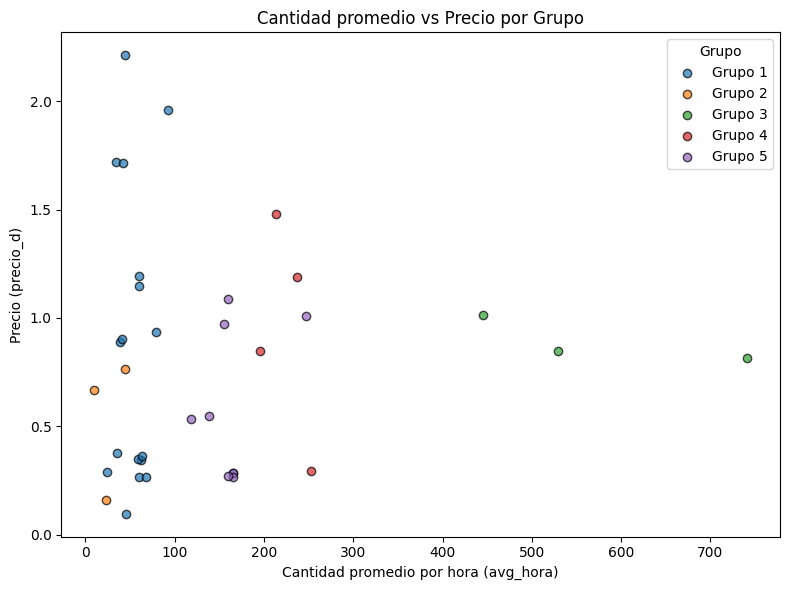

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular la media por planta dentro de cada grupo
df_mean = mean_por_planta_y_hora(df)

# Promedio horario total (h1-h24) → eje X
df_mean['avg_hora'] = df_mean[[f"h{i}" for i in range(1,25)]].mean(axis=1)

# Definir un colormap para 10 grupos
cmap = plt.get_cmap('tab10')  # 10 colores distintos
grupos_unicos = sorted(df_mean['Grupo'].unique())
colores = {g: cmap(i) for i, g in enumerate(grupos_unicos)}

plt.figure(figsize=(8,6))
for g in grupos_unicos:
    sub = df_mean[df_mean['Grupo'] == g]
    plt.scatter(
        sub['avg_hora'],
        sub['precio_d'],
        c=[colores[g]],
        label=f'Grupo {g}',
        alpha=0.7,
        edgecolors='k'
    )

plt.xlabel('Cantidad promedio por hora (avg_hora)')
plt.ylabel('Precio (precio_d)')
plt.title('Cantidad promedio vs Precio por Grupo')
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()



In [40]:
phi_by_plant = sample_day_batches_phi(
  df,
  H=H,
  seed=seed,
  day_col="Fecha",
  id_col="id_planta",
  phi_col="phi",
  price_col="precio_d",
  plant_ids=plant_ids,
  replace=True,
  min_active_plants=1,
  pick="random",
)

In [41]:


# 1) inferir input_dim desde obs_batch_by_pid
sample_obs = np.asarray(next(iter(phi_by_plant.values())))
input_dim = 1 if sample_obs.ndim == 1 else int(sample_obs.shape[1])

# 2) volver a correr el entry point con input_dim consistente
policies_group = policies_and_beta_profile_grouped(
    t=0,
    df=df,                      # df con columna "Grupo"
    obs_batch_by_pid=phi_by_plant,
    id_col="id_planta",
    grupo_col="Grupo",
    phi_col="phi",
    input_dim=input_dim,        # <- 24 si obs es (H,24)
    hidden=(32,64,128,128,64,32),
    device="auto",
    enforce_beta_ge_phi=True,
    min_margin=1e-6,
    floor_mode="max",
)

In [42]:
# 1) corre NPGA
theta_best_by_gid, nets_best_by_gid, Beta_best, eq_list_best, hist = npga_fit_by_group(
    df=df,
    theta_init_by_gid=policies_group["theta_by_gid"],
    obs_batch_by_pid=phi_by_plant,
    phi_batch_by_pid=phi_by_plant,
    pids=policies_group["pids"],
    compute_equilibrio_dispatch=compute_equilibrio_dispatch,
    joint_utility_from_eq_list=joint_utility_from_eq_list,
    T=T, P=P, sigma=sigma, eta=eta,
    pricing=pricing,
    unmet_price="max_accepted",
    device="auto",
)
# 2) crea 'out' compatible con extract_npga_panel_df
out = {
    "pricing": pricing,
    "pids": policies_group["pids"],
    "theta_best_by_gid": theta_best_by_gid,
    "nets_best_by_gid": nets_best_by_gid,
    "Beta_best": Beta_best,
    "history": {
        # LO QUE TE FALTABA:
        "eq_list": eq_list_best,          # <- ahora extract_npga_panel_df lo encuentra
        "phi_batch": phi_by_plant,        # <- si tu extractor lo exige
        # opcional (si tu extractor lo usa):
        "Beta": [Beta_best],              # si espera lista por iteración
        # trazas que ya tenías:
        "trace": hist,                    # para no perder tus logs
    }
}



NPGA (t): 100%|██████████| 1000/1000 [1:11:18<00:00,  4.28s/it, U_mean=nan, sec/t=4.52, ETA_min=0.0]


## SAVE

In [43]:
import numpy as np
import pandas as pd


def extract_npga_panel_df(
    out: dict,
    *,
    qty_key: str = "cantidades_despachadas",
    price_key: str = "precio24",
    bid_key: str = "beta",
    phi_key: str = "phi_batch",
    eq_key: str = "eq_list",
    phi_reduce: str = "max",   # si phi[h,:] no es 24: "max" o "mean"
) -> pd.DataFrame:
    """
    Construye un panel a nivel (t, h, id_planta):
      columnas: id_planta, t, h, bid, cantidades_despachadas, precio24, phi

    Convención (según tu ejemplo):
      - out['history']['eq_list'][h] es un dict de un escenario (batch h),
        con keys globales ('I','demanda','price24',...) y keys por planta (1..I).
      - out['history']['phi_batch'][pid] es un array (H,24) (o (H,) o (H,d)).
        Para (pid,h) tomas phi_arr[h,:] (o repites/colapsas si no es 24).
    """
    if "history" not in out or out["history"] is None:
        raise KeyError("out no tiene 'history'")

    hist = out["history"]
    if eq_key not in hist:
        raise KeyError(f"out['history'] no tiene '{eq_key}'")
    if phi_key not in hist:
        raise KeyError(f"out['history'] no tiene '{phi_key}'")

    eq_hist = hist[eq_key]
    phi_hist = hist[phi_key]

    # pids (si no está, intenta leerlo del eq[ 'I' ])
    pids = list(out.get("pids", []))
    if not pids:
        # intenta inferir desde el primer eq
        if isinstance(eq_hist, (list, tuple)) and len(eq_hist) > 0 and isinstance(eq_hist[0], dict) and "I" in eq_hist[0]:
            pids = [int(x) for x in np.asarray(eq_hist[0]["I"]).reshape(-1).tolist()]
        else:
            raise KeyError("No encuentro out['pids'] y no pude inferir pids desde eq['I'].")

    I = len(pids)
    pid_to_j = {pid: j for j, pid in enumerate(pids)}
    try:
        max_pid = int(np.max([int(p) for p in pids]))
    except Exception:
        max_pid = None

    def _get_key_like(d: dict, key):
        if key in d:
            return d[key]
        try:
            ik = int(key)
            if ik in d:
                return d[ik]
        except Exception:
            pass
        sk = str(key)
        if sk in d:
            return d[sk]
        raise KeyError(f"key={key} no está. keys ejemplo={list(d.keys())[:10]}")

    def _ensure_24(x):
        a = np.asarray(x, dtype=float).reshape(-1)
        if a.size == 24:
            return a
        if a.size == 1:
            return np.repeat(float(a[0]), 24)
        raise ValueError(f"vector size {a.size}, esperaba 24 o 1")

    def _phi24_from_arr(A, h_idx: int):
        A = np.asarray(A, dtype=float)
        if A.ndim == 1:
            # (H,)
            return np.repeat(float(A[h_idx]), 24)
        if A.ndim == 2 and A.shape[1] == 24:
            # (H,24)
            return A[h_idx, :].astype(float)
        if A.ndim == 2:
            # (H,d) con d!=24: colapsa a escalar y repite
            v = A[h_idx, :].astype(float)
            if phi_reduce == "mean":
                return np.repeat(float(np.nanmean(v)), 24)
            return np.repeat(float(np.nanmax(v)), 24)
        raise ValueError(f"phi shape no soportado: {A.shape}")

    def _get_phi_arr_for_pid(phi_container, pid, j):
        # Caso A: dict pid -> array
        if isinstance(phi_container, dict):
            return _get_key_like(phi_container, pid)

        A = np.asarray(phi_container)

        # Caso B: array/list indexado por planta en eje 0
        # Heurística de índice:
        #   - si eje0 == I: usa j
        #   - si pid es int y eje0 > max_pid: usa pid
        #   - fallback: usa j
        pid_idx = j
        try:
            pid_int = int(pid)
            if A.ndim >= 1 and A.shape[0] != I and max_pid is not None and A.shape[0] >= max_pid + 1:
                pid_idx = pid_int
        except Exception:
            pid_idx = j

        if A.ndim >= 1 and A.shape[0] == I:
            pid_idx = j

        return A[pid_idx]

    # Normaliza eq_hist a iteración (t,h,eq_dict)
    def _iter_eq(eq_hist_obj):
        # Caso 1: eq_hist es lista de escenarios (H)  -> t=0
        if isinstance(eq_hist_obj, (list, tuple)):
            if len(eq_hist_obj) == 0:
                return
            # si el primer elemento es dict por planta (como tu ejemplo), entonces es lista por h
            if isinstance(eq_hist_obj[0], dict) and any((pid in eq_hist_obj[0]) or (str(pid) in eq_hist_obj[0]) for pid in pids):
                for h, eq in enumerate(eq_hist_obj):
                    yield 0, h, eq
                return
            # si es lista por t y cada t contiene lista/dict de h
            for t, eq_t in enumerate(eq_hist_obj):
                if isinstance(eq_t, (list, tuple)):
                    for h, eq in enumerate(eq_t):
                        yield t, h, eq
                elif isinstance(eq_t, dict):
                    # dict h->eq o dict por planta (single h)
                    if any((pid in eq_t) or (str(pid) in eq_t) for pid in pids):
                        yield t, 0, eq_t
                    else:
                        for h, eq in enumerate(eq_t.values()):
                            yield t, h, eq
                else:
                    raise TypeError(f"eq_list[{t}] no soportado: {type(eq_t)}")
            return

        # Caso 2: eq_hist es dict (por t o por h)
        if isinstance(eq_hist_obj, dict):
            # si parece dict por planta (single eq)
            if any((pid in eq_hist_obj) or (str(pid) in eq_hist_obj) for pid in pids):
                yield 0, 0, eq_hist_obj
                return
            # si es dict por t -> ...
            for t_key, eq_t in eq_hist_obj.items():
                t = int(t_key) if str(t_key).isdigit() else t_key
                if isinstance(eq_t, (list, tuple)):
                    for h, eq in enumerate(eq_t):
                        yield t, h, eq
                elif isinstance(eq_t, dict):
                    if any((pid in eq_t) or (str(pid) in eq_t) for pid in pids):
                        yield t, 0, eq_t
                    else:
                        for h, eq in enumerate(eq_t.values()):
                            yield t, h, eq
                else:
                    raise TypeError(f"eq_list[{t_key}] no soportado: {type(eq_t)}")
            return

        raise TypeError(f"eq_list no soportado: {type(eq_hist_obj)}")

    rows = []
    for t, h, eq in _iter_eq(eq_hist):
        for pid in pids:
            eq_pid = _get_key_like(eq, pid)

            bid = float(eq_pid[bid_key]) if bid_key in eq_pid else np.nan
            q24 = _ensure_24(eq_pid[qty_key])
            p24 = _ensure_24(eq_pid[price_key])

            phi_arr_pid = _get_phi_arr_for_pid(phi_hist, pid, pid_to_j[pid])
            phi24 = _phi24_from_arr(phi_arr_pid, h)

            rows.append({
                "id_planta": int(pid) if str(pid).isdigit() else pid,
                "t": int(t) if str(t).isdigit() else t,
                "h": int(h),
                "bid": float(bid),
                "cantidades_despachadas": q24.tolist(),
                "precio24": p24.tolist(),
                "phi": phi24.tolist(),
            })

    return pd.DataFrame(rows)


In [44]:
import os
import pandas as pd


import os
import pandas as pd


def export_panel_to_drive(
    *,
    panel: pd.DataFrame,
    out_dir: str,
    fname_prefix: str,
) -> dict:
    os.makedirs(out_dir, exist_ok=True)

    panel_path = os.path.join(out_dir, f"panel_{fname_prefix}.csv")
    panel.to_csv(panel_path, index=False)

    return {"panel_path": panel_path}



ejecutar save

In [48]:
import torch

if pricing=='uniform':
  # Uniform
  panel_uniform = extract_npga_panel_df(out)
  export_panel_to_drive(panel=panel_uniform, out_dir="5redes/cluster5", fname_prefix="uniform")
  torch.save(out['theta_best_by_gid'], "5redes/cluster5/theta_best_by_gid_uniform.pth")
  path = "5redes/cluster5/nets_best_by_gid_uniform.pt"


if pricing=='pay_as_bid':
  panel_pay_as_bid = extract_npga_panel_df(out)
  export_panel_to_drive(panel=panel_pay_as_bid, out_dir="5redes/cluster5", fname_prefix="pay_as_bid")
  torch.save(out['theta_best_by_gid'], "5redes/cluster5/theta_best_by_gid_pab.pth")
  path = "5redes/cluster5/nets_best_by_gid_payasbid5R.pt"


In [46]:
import torch


to_save = {
    int(gid): net.state_dict()
    for gid, net in out["nets_best_by_gid"].items()
}

torch.save(to_save, path)

In [49]:
panel_uniform

,id_planta,t,h,bid,cantidades_despachadas,precio24,phi
0,1,0,0,1.206525,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0184093355959, 0.0184093355959, 0.018409335..."
1,2,0,0,NaN,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
2,7,0,0,1.271632,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0901810392978, 0.0901810392978, 0.090181039..."
3,8,0,0,1.241368,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.059917420935, 0.059917420935, 0.05991742093..."
4,3,0,0,1.065041,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.14735514735570002, 0.14735514735570002, 0.1..."
...,...,...,...,...,...,...,...
4207,36,0,116,2.625123,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.3621591831742001, 1.3621591831742001, 1.362..."
4208,28,0,116,2.786128,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.5980124675252, 1.5980124675252, 1.598012467..."
4209,27,0,116,2.881741,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.6936250511211999, 1.6936250511211999, 1.693..."
4210,18,0,116,NaN,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
